# Humanos vs. IA en gestión de cobranza

**Muestra:** 100 llamadas de cobranza en español(50 gestionadas por agentes humanos y 50 por un agente de IA), transformadas en tablas mediante el pipeline de `data_extraction/` 

**Pregunta central:** ¿existen diferencias estadísticamente sustentables en el desempeño de ambos tipos de agente? Si existen, ¿qué conductas las explican y qué debería cambiar para cerrarlas?

| Bloque | Pregunta |
|---|---|
|  Embudo | ¿Dónde se pierde el resultado? |
|  Tamaños de efecto | ¿Quién es mejor y en qué dimensión? |
|  Resultado final | ¿Se sostiene la ventaja sobre toda la escala de resultados? |
|  Objeciones | ¿La IA elige peores técnicas o las ejecuta peor? |
|  Ofertas | ¿Qué ofrece cada agente, en qué términos y con qué aceptación? |
|  Respuesta a objeciones | ¿Cómo responde cada agente y cuántas negativas terminan en compromiso? |

## 0. Configuración

In [1]:
import json
import re
import textwrap
import unicodedata
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import display
from matplotlib.transforms import offset_copy
from scipy import stats
from statsmodels.miscmodels.ordinal_model import OrderedModel
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_confint, proportion_effectsize
from statsmodels.tools.sm_exceptions import IterationLimitWarning

SEED = 20260915
N_BOOT = 2000
DATA_DIR = Path("../../data/cleaned")
EXTRACTION_DIR = Path("../../data_extraction/data")  # transcripciones y turnos: fuera del repositorio público
OUT_DIR = Path("../outputs")
TABLES_DIR = OUT_DIR / "tablas"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
warnings.simplefilter("ignore", pd.errors.PerformanceWarning)  # columnas derivadas añadidas una a una: sin efecto en resultados

GROUP_LABEL = {"human": "Humano", "ai": "IA"}
GROUPS = ["Humano", "IA"]
# Paleta sobria para lectura directiva: azul para el equipo humano, naranja de acento para la IA, grises para el contexto.
PALETTE = {"Humano": "#1F4E79", "IA": "#E8702A"}
AGENT_LABEL = {"Humano": "Equipo humano", "IA": "Agente de IA"}  # nombres largos, solo para la leyenda
TINTS = {"Humano": "#AFC6DA", "IA": "#F7C7A6"}
POSITIVE, POSITIVE_SOFT = "#2E7D5B", "#A9CDBB"  # desenlaces favorables
INK, INK_2, MUTED, NEUTRAL = "#111111", "#4D4D4D", "#8C8C8C", "#D9D9D9"

sns.set_theme(style="white")
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.dpi": 300,
    "axes.edgecolor": NEUTRAL, "axes.labelcolor": INK_2, "axes.labelsize": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "text.color": INK,
    "xtick.color": INK_2, "ytick.color": INK_2, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "legend.fontsize": 11, "legend.title_fontsize": 11, "legend.frameon": False, "axes.grid": False,
})
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

### 0.1 Diccionario de etiquetas


In [2]:
LABELS = {
    # Resultado
    "ptp_f": "Compromiso de pago", "promesa_firme_f": "Promesa firme",
    "final_outcome_rank": "Resultado final de la llamada", "pct_objections_resolved": "Objeciones resueltas (%)",
    # Negociación y descubrimiento
    "had_negotiation_f": "Hubo negociación", "n_offers_agent": "Ofertas del agente",
    "n_counteroffers_client": "Contraofertas del cliente", "pct_ofertas_descuento": "Ofertas con descuento (%)",
    "motivo_indagado": "Obtiene el motivo de no pago", "n_objections": "Objeciones del cliente",
    # Dinámica conversacional
    "conv_duration_s": "Duración de la conversación (s)", "agent_talk_share": "Participación del agente en el habla",
    "agent_latency_median_s": "Tiempo en responder del agente (s)", "silencio_muerto_por_min": "Silencio muerto (s/min)",
    "silence_pct": "Silencio total (%)", "interruptions_per_min_client": "Interrupciones del cliente (por min)",
    "interruptions_per_min_agent": "Interrupciones del agente (por min)", "words_per_min_agent": "Velocidad del agente (palabras/min)",
    "max_agent_monologue_s": "Monólogo más largo del agente (s)", "mean_turn_s_agent": "Turno medio del agente (s)",
    "backchannels_agent_per_min": "Señales de escucha del agente (por min)", "mechanical_repetition_f": "Repetición mecánica",
    "agent_misunderstood": "Turnos con malentendido del agente", "preguntas_por_min": "Preguntas del agente (por min)",
    "cortesia_por_min": "Marcadores de cortesía (por min)", "lexical_richness_mattr": "Riqueza del vocabulario del agente",
    # Cumplimiento
    "cumplimiento_regulatorio": "Cumplimiento regulatorio (%)", "gestion_cobro": "Guion de cobro completado (%)",
    "validates_identity_before_disclosing_f": "Valida identidad antes de revelar la deuda",
    "identifies_self_f": "Se identifica con nombre y entidad", "recording_notice_f": "Avisa que la llamada es grabada",
    "mentions_credit_bureaus_f": "Menciona centrales de riesgo", "offers_payment_channels_f": "Ofrece canales de pago",
    # Calidad percibida (puntuación de 1 a 5)
    "clarity": "Claridad (1-5)", "empathy": "Empatía (1-5)", "active_listening": "Escucha activa (1-5)",
    "objection_handling": "Manejo de objeciones (1-5)", "control_focus": "Control y foco (1-5)",
    "professionalism": "Profesionalismo (1-5)",
    # Cliente
    "sentiment_delta": "Cambio de ánimo del cliente", "client_escalation": "Escalada vocal del cliente",
    "client_expresses_annoyance_f": "Cliente expresa molestia",
    # Índices compuestos
    "fluidez_idx": "Fluidez de la conversación", "escucha_idx": "Escucha del agente",
    # Respuesta a objeciones (reglas léxicas sobre transcripciones)
    "validacion_empatica": "Valida la situación del cliente", "pregunta_abierta": "Pregunta abierta de indagación",
    "mejora_sentimiento": "Mejora el ánimo del cliente", "latencia_respuesta_s": "Tiempo en responder (s)",
    "delta_sentimiento": "Cambio de ánimo tras la respuesta",
}

def label(col):
    return LABELS.get(col, col)

### 0.2 Funciones auxiliares

In [3]:
def wilson_ci(k, n):
    return proportion_confint(k, n, alpha=0.05, method="wilson")


def newcombe_diff_ci(k1, n1, k2, n2):
    """IC 95% de Newcombe (híbrido de Wilson) para p1 - p2."""
    p1, p2 = k1 / n1, k2 / n2
    (l1, u1), (l2, u2) = wilson_ci(k1, n1), wilson_ci(k2, n2)
    d = p1 - p2
    return d - np.hypot(p1 - l1, u2 - p2), d + np.hypot(u1 - p1, p2 - l2)


def fisher_p(k1, n1, k2, n2):
    return stats.fisher_exact([[k1, n1 - k1], [k2, n2 - k2]]).pvalue


def cliffs_delta(x, y):
    """P(X > Y) - P(X < Y). Para variables 0/1 coincide con la diferencia de proporciones."""
    return np.sign(np.subtract.outer(np.asarray(x, float), np.asarray(y, float))).mean()


def bootstrap_ci(stat, x, y, n_boot=N_BOOT, seed=SEED):
    """IC percentil 95% remuestreando cada muestra por separado."""
    rng = np.random.default_rng(seed)
    x, y = np.asarray(x, float), np.asarray(y, float)
    reps = [stat(rng.choice(x, x.size), rng.choice(y, y.size)) for _ in range(n_boot)]
    return tuple(np.percentile(reps, [2.5, 97.5]))


def bootstrap_frame(df, fn, strata="grupo", cluster=None, n_boot=N_BOOT, seed=SEED):
    """Replica fn(df) sobre remuestras estratificadas por grupo (y por conglomerado si se indica)."""
    rng = np.random.default_rng(seed)
    if cluster is None:
        reps = [fn(df.groupby(strata, group_keys=False, observed=True)
                   .sample(frac=1, replace=True, random_state=rng).reset_index(drop=True))
                for _ in range(n_boot)]
    else:
        blocks = dict(tuple(df.groupby(cluster)))
        ids = df.drop_duplicates(cluster).groupby(strata, observed=True)[cluster].apply(np.asarray)
        reps = [fn(pd.concat([blocks[i] for g in ids for i in rng.choice(g, g.size)], ignore_index=True))
                for _ in range(n_boot)]
    return pd.DataFrame(reps)


def kitagawa(df, stratum_col, outcome_col, ref="Humano", other="IA"):
    """Descompone la diferencia de tasas (ref - other) en efecto composición y efecto tasa (Kitagawa, 1955)."""
    w = pd.crosstab(df["grupo"], df[stratum_col], normalize="index")
    r = df.groupby(["grupo", stratum_col])[outcome_col].mean().unstack().reindex(columns=w.columns)
    r = r.apply(lambda col: col.fillna(col.mean()))  # estrato vacío en un grupo: no aporta efecto tasa
    composition = ((w.loc[ref] - w.loc[other]) * (r.loc[ref] + r.loc[other]) / 2).sum()
    rate = ((r.loc[ref] - r.loc[other]) * (w.loc[ref] + w.loc[other]) / 2).sum()
    return pd.Series({"Brecha total": composition + rate, "Efecto composición": composition, "Efecto tasa": rate})


def e_value(rr):
    """E-value de VanderWeele y Ding para una razón de riesgos."""
    rr = max(rr, 1 / rr)
    return rr + np.sqrt(rr * (rr - 1))


def cronbach_alpha(items):
    items = items.dropna()
    k = items.shape[1]
    return k / (k - 1) * (1 - items.var(ddof=1).sum() / items.sum(axis=1).var(ddof=1))


def pct(x, decimals=0):
    return f"{x:.{decimals}%}"


def read_table(name):
    """Lee una tabla limpia en CSV con los tipos del diccionario de datos: tri-estado como texto y listas separadas por ';'."""
    path = DATA_DIR / f"{name}.csv"
    dictionary = pd.read_csv(DATA_DIR / "data_dictionary.csv")
    types = dictionary[dictionary["table"].eq(name)].set_index("variable")["type"]
    columns = pd.read_csv(path, nrows=0).columns
    table = pd.read_csv(path, dtype={c: str for c in columns if types.get(c) == "tri"})
    for col in (c for c in columns if types.get(c) == "list"):
        table[col] = table[col].fillna("").str.split(";").map(lambda items: [i for i in items if i])
    table["grupo"] = pd.Categorical(table["group"].map(GROUP_LABEL), categories=GROUPS)
    return table


GROUP_FORMULA = "C(grupo, Treatment('Humano'))"
GROUP_TERM = f"{GROUP_FORMULA}[T.IA]"
RATE_FORMAT = {"Humano": "{:.0%}", "IA": "{:.0%}", "n Humano": "{:.0f}", "n IA": "{:.0f}",
               "Diferencia IA − Humano (pp)": "{:+.0f}", "p": "{:.4f}"}


def fit_gee(formula, data, family=None):
    """GEE agrupado por llamada: las observaciones de una llamada no son independientes. Usa correlación intercambiable y,
    si no converge, correlación independiente, que conserva los errores estándar robustos por conglomerado."""
    family = family or sm.families.Binomial()
    with warnings.catch_warnings():
        warnings.simplefilter("error", IterationLimitWarning)
        try:
            return smf.gee(formula, groups="call_id", data=data, family=family, cov_struct=sm.cov_struct.Exchangeable()).fit()
        except IterationLimitWarning:
            return smf.gee(formula, groups="call_id", data=data, family=family, cov_struct=sm.cov_struct.Independence()).fit()


def gee_odds_ratio(res, term):
    lo, hi = np.exp(res.conf_int().loc[term])
    return {"OR": np.exp(res.params[term]), "IC inf": lo, "IC sup": hi, "p": res.pvalues[term]}


def compare_rate(df, outcome, clustered):
    """Proporción por grupo y diferencia IA − Humano. p-valor: GEE por llamada si hay varias filas por llamada; Fisher si no."""
    df = df.dropna(subset=[outcome])
    k = df.groupby("grupo", observed=True)[outcome].agg(["sum", "count"]).astype(int)
    (kh, nh), (ka, na) = k.loc["Humano"], k.loc["IA"]
    p = gee_odds_ratio(fit_gee(f"{outcome} ~ {GROUP_FORMULA}", df), GROUP_TERM)["p"] if clustered else fisher_p(kh, nh, ka, na)
    return {"Humano": kh / nh, "IA": ka / na, "n Humano": nh, "n IA": na, "Diferencia IA − Humano (pp)": 100 * (ka / na - kh / nh), "p": p}


def call_permutation_p(df, stat, n_perm=N_BOOT, seed=SEED):
    """p-valor por permutación de la etiqueta de grupo entre llamadas: respeta la agrupación de observaciones por llamada."""
    rng = np.random.default_rng(seed)
    labels = df.drop_duplicates("call_id").set_index("call_id")["grupo"].astype(str)
    observed = stat(df)
    hits = sum(stat(df.assign(grupo=df["call_id"].map(pd.Series(rng.permutation(labels.to_numpy()), index=labels.index))))
               >= observed for _ in range(n_perm))
    return (hits + 1) / (n_perm + 1)


def rate_table(df, by, outcome):
    """Conteos, tasa e IC 95% de Wilson de un resultado binario por categoría y tipo de agente."""
    out = (df.dropna(subset=[outcome]).groupby([by, "grupo"], observed=True)[outcome]
           .agg(k="sum", n="count").reset_index().rename(columns={by: "categoria"}))
    out["tasa"] = out["k"] / out["n"]
    out[["ci_lo", "ci_hi"]] = np.array([wilson_ci(k, n) for k, n in zip(out["k"], out["n"])])
    return out


def indicator_rates(frames):
    """{nombre del indicador: (tabla, columna binaria)} -> tabla larga de tasas por indicador y tipo de agente."""
    return pd.concat([rate_table(df.assign(indicador=name), "indicador", col) for name, (df, col) in frames.items()],
                     ignore_index=True)


# --- Presentación de gráficos: títulos breves, etiquetas directas y un pie que explica el hallazgo ---------------------

def save_fig(fig, name):
    fig.savefig(OUT_DIR / f"{name}.png", dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()


def chart_title(fig, title, subtitle=None):
    """Título breve arriba de la figura y, opcionalmente, una línea de alcance. El detalle va en el pie."""
    def above_top(points):
        return offset_copy(fig.transFigure, fig=fig, y=points, units="points")
    fig.text(0.005, 1, title, transform=above_top(28 if subtitle else 10), ha="left", va="bottom",
             fontsize=15, fontweight="bold", color=INK)
    if subtitle:
        fig.text(0.005, 1, subtitle, transform=above_top(10), ha="left", va="bottom", fontsize=11, color=INK_2)


def caption(fig, shows, finding, conclusion, pad_points=22):
    """Pie de figura: un párrafo breve que encadena qué muestra el gráfico, qué dice el dato y qué implica.

    Los tres elementos se reciben por separado para no olvidar ninguno, pero se imprimen seguidos y sin rótulo:
    una etiqueta del tipo "Hallazgo:" ocupa línea y no añade nada que el propio texto no diga ya.
    """
    text = " ".join(part.strip() for part in (shows, finding, conclusion) if part)
    below = offset_copy(fig.transFigure, fig=fig, y=-pad_points, units="points")
    fig.text(0.005, 0, textwrap.fill(text, min(int(fig.get_figwidth() * 13), 150)), transform=below,
             ha="left", va="top", fontsize=10, color=INK_2, linespacing=1.5)


def chart_frame(ax, title=None, xlabel=None, ylabel=None, keep=()):
    """Marco limpio: sin cuadrícula y sin más ejes que los imprescindibles, porque los valores van sobre las barras."""
    if title:
        ax.set_title(title, loc="left", fontsize=13, fontweight="bold", color=INK, pad=26)
        # separación fija: así los títulos de dos paneles quedan a la misma altura lleven o no unidad debajo
    ax.set_xlabel(xlabel or "", fontsize=11, color=INK_2, labelpad=10)
    ax.set_ylabel("")
    if ylabel:  # en horizontal sobre el gráfico: el rótulo girado 90 grados es el primero que se pierde al leer rápido
        ax.annotate(ylabel, (0, 1), xycoords="axes fraction", xytext=(0, 8), textcoords="offset points",
                    ha="left", va="bottom", fontsize=11, color=INK_2)
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(side in keep)
    ax.tick_params(axis="both", length=0, labelsize=11, colors=INK_2)
    ax.grid(False)


def agent_legend(fig, loc="upper right", bbox=(0.995, 0.99)):
    """Leyenda de color por tipo de agente, en recuadro y en la misma posición en todos los gráficos.

    Va a nivel de figura y no de panel para que dos gráficos contiguos compartan una sola leyenda. Se ancla al
    extremo derecho de la banda superior y no bajo el título, donde interrumpía la entrada natural de la lectura
    (título, bajada, datos) y dejaba la esquina derecha vacía.
    """
    handles = [plt.Rectangle((0, 0), 1, 1, color=PALETTE[g], label=AGENT_LABEL[g]) for g in GROUPS]
    legend = fig.legend(handles=handles, loc=loc, bbox_to_anchor=bbox, ncol=2, frameon=True,
                        framealpha=1, edgecolor=NEUTRAL, fontsize=11, handlelength=1.2, handleheight=1.2,
                        borderpad=0.6, columnspacing=1.2)
    legend.get_frame().set_linewidth(1)
    return legend


def _row_y(j, n_rows, gap_after):
    """Posición vertical de la fila j, con un hueco extra si se separa un bloque del resto."""
    return (n_rows - 1 - j) + (0.7 if gap_after is not None and j <= gap_after else 0.0)


def grouped_bars(ax, rates, order, tick_labels=None, xmax=None, gap_after=None):
    """Barras horizontales por tipo de agente, con el valor a la derecha de cada barra.

    Un único color por tipo de agente en todos los gráficos y la etiqueta con el valor a secas: la lectura se apoya
    en la leyenda y en la posición, no en tonos intermedios ni en texto pegado al dato.
    """
    height = 0.36
    xmax = xmax or min(1.0, np.ceil(rates["tasa"].max() * 10) / 10 + 0.05)
    for i, g in enumerate(GROUPS):
        block = rates[rates["grupo"].eq(g)].set_index("categoria").reindex(order)
        for j, (_, row) in enumerate(block.iterrows()):
            if pd.isna(row["tasa"]):
                continue
            y = _row_y(j, len(order), gap_after) + (0.5 - i) * height
            ax.barh(y, row["tasa"], height, color=PALETTE[g], zorder=2)
            ax.annotate(f"{row['tasa']:.0%}", (row["tasa"], y), xytext=(8, 0), textcoords="offset points",
                        va="center", fontsize=11, fontweight="bold", color=INK)
    ax.set_yticks([_row_y(j, len(order), gap_after) for j in range(len(order))], list(tick_labels or order))
    ax.set_xlim(0, xmax * 1.22)
    ax.set_xticks([])

## 1. Construcción de la base analítica

Se parte de cuatro tablas: `calls` (una fila por llamada), `turns`, `objections` y `offers`. Sobre ellas se construyen variables que responden preguntas de negocio y no solo describen la señal:

- **Etapas del embudo**, anidadas por construcción: contesta una persona, contacto con el titular, compromiso de pago y promesa firme.
- **Tasas por minuto** (silencio muerto, preguntas, cortesía), para que las llamadas más largas no inflen los conteos.
- **Negociación:** porcentaje de ofertas del agente que son descuento, que funciona como proxy del costo de la concesión.
- **Descubrimiento:** si el agente obtiene el motivo de no pago, la información que permite adaptar la oferta.
- **Cumplimiento dividido en dos:** *regulatorio* (se identifica, avisa la grabación, valida la identidad antes de revelar la deuda) y *guion de cobro* (monto, fecha de vencimiento, canales, centrales de riesgo). Se excluyen el cierre cortés, por posible truncado de grabaciones, y el resumen del acuerdo, que solo existe si hubo compromiso y filtraría el resultado.
- **Índices compuestos:** media de z-scores orientados, de modo que un valor mayor siempre es mejor. Se calculan sobre las llamadas con el titular.

In [4]:
calls, objections, offers = (read_table(name) for name in ("calls", "objections", "offers"))

TRI_STATE = {"true": 1.0, "false": 0.0, "na": np.nan}
REGULATORY_ITEMS = ["identifies_self", "recording_notice", "validates_identity_before_disclosing"]
COLLECTION_ITEMS = ["states_amount", "states_due_date", "offers_payment_channels", "mentions_credit_bureaus"]
BOOL_COLS = ["ptp", "had_negotiation", "mechanical_repetition", "client_expresses_annoyance"]

for col in REGULATORY_ITEMS + COLLECTION_ITEMS:
    calls[f"{col}_f"] = calls[col].map(TRI_STATE).astype(float)
for col in BOOL_COLS:
    calls[f"{col}_f"] = calls[col].astype(float)

calls["contesta_persona"] = ~calls["contact_type"].isin(["no_answer", "voicemail", "ivr"])
calls["es_titular"] = calls["contact_type"].eq("account_holder")
calls["promesa_firme_f"] = calls["ptp_type_commitment"].eq("firm").astype(float)

conv_min = calls["conv_duration_s"] / 60
calls["silencio_muerto_por_min"] = calls["dead_air_s"] / conv_min
calls["preguntas_por_min"] = calls["agent_questions"] / conv_min
calls["cortesia_por_min"] = calls["politeness_markers"] / conv_min
calls["motivo_indagado"] = calls["non_payment_reasons"].map(lambda r: float("not_stated" not in r))
calls["cumplimiento_regulatorio"] = calls[[f"{c}_f" for c in REGULATORY_ITEMS]].mean(axis=1)
calls["gestion_cobro"] = calls[[f"{c}_f" for c in COLLECTION_ITEMS]].mean(axis=1)

agent_offers = offers[offers["proposed_by"].eq("agent")]
calls = calls.merge(
    agent_offers.groupby("call_id")["type"].agg(lambda t: t.eq("discount_forgiveness").mean())
    .rename("pct_ofertas_descuento"),
    on="call_id", how="left",
)

# Integridad del embudo: cada etapa implica la anterior.
assert not (calls["es_titular"] & ~calls["contesta_persona"]).any()
assert not (calls["ptp_f"].eq(1) & ~calls["es_titular"]).any()
assert not (calls["promesa_firme_f"].eq(1) & calls["ptp_f"].eq(0)).any()

### 1.1 Índices compuestos y consistencia interna
- **Fluidez:** latencia de respuesta, silencio muerto por minuto y silencio total. Los tres puntúan en negativo.
- **Escucha:** participación del cliente en el habla y señales de escucha, en positivo; repetición mecánica y malentendidos, en negativo.

El alfa de Cronbach indica si los ítems miden un mismo constructo. Si el alfa es bajo, el índice se interpreta como *formativo*: resume conductas deseables sin suponer una causa latente común.

In [5]:
titulares = calls[calls["es_titular"]].copy()

INDEX_ITEMS = {
    "fluidez_idx": {"agent_latency_median_s": -1, "silencio_muerto_por_min": -1, "silence_pct": -1},
    "escucha_idx": {"agent_talk_share": -1, "backchannels_agent_per_min": 1, "mechanical_repetition_f": -1, "agent_misunderstood": -1},
}

alpha_rows = []
for name, items in INDEX_ITEMS.items():
    z = pd.DataFrame({c: s * (titulares[c] - titulares[c].mean()) / titulares[c].std(ddof=0) for c, s in items.items()})
    titulares[name] = z.mean(axis=1)
    alpha_rows.append({"Índice": label(name), "Ítems": len(items), "Alfa de Cronbach": cronbach_alpha(z)})

display(pd.DataFrame(alpha_rows).style.format({"Alfa de Cronbach": "{:.2f}"}).hide(axis="index"))

summary = (calls.groupby("grupo", observed=True)
           .agg(Llamadas=("call_id", "size"), Titulares=("es_titular", "sum"),
                Duracion_mediana_s=("conv_duration_s", "median"), SNR_mediana_dB=("snr_db", "median"))
           .rename(columns={"Duracion_mediana_s": "Duración mediana (s)", "SNR_mediana_dB": "Relación señal/ruido mediana (dB)"}))
display(summary.style.format(precision=1))

Índice,Ítems,Alfa de Cronbach
Fluidez de la conversación,3,0.87
Escucha del agente,4,0.39


,Llamadas,Titulares,Duración mediana (s),Relación señal/ruido mediana (dB)
grupo,,,,
Humano,50,46,155.6,11.6
IA,50,35,144.5,18.6


**Lectura.** El índice de fluidez es consistente (alfa = 0.87). El de escucha no lo es (alfa = 0.39) y se usa como índice formativo. La relación señal/ruido es mayor en la IA (18.6 frente a 11.6 dB) por la voz sintética; como coincide casi por completo con el grupo, no se usa como control, porque absorbería el efecto que se quiere medir.

## 2. Embudo de gestión

**Pregunta:** ¿en qué etapa se separan los dos grupos?

**Método.** Cada etapa se mide como proporción acumulada sobre las 50 llamadas de cada grupo, con IC 95% de Wilson (apropiado para n pequeño y proporciones extremas). La diferencia Humano − IA lleva un IC de Newcombe y un test exacto de Fisher.

In [6]:
STAGES = {
    "Llamadas realizadas": pd.Series(True, index=calls.index),
    "Contesta una persona": calls["contesta_persona"],
    "Contacto con el titular": calls["es_titular"],
    "Compromiso de pago": calls["ptp_f"].eq(1),
    "Promesa firme": calls["promesa_firme_f"].eq(1),
}
n_group = calls["grupo"].value_counts()

funnel_rows = []
for stage, mask in STAGES.items():
    k = mask.groupby(calls["grupo"], observed=True).sum()
    kh, ka, nh, na = int(k["Humano"]), int(k["IA"]), int(n_group["Humano"]), int(n_group["IA"])
    lo, hi = newcombe_diff_ci(kh, nh, ka, na)
    funnel_rows.append({
        "Etapa": stage, "Humano": kh / nh, "IA": ka / na, "Diferencia (pp)": 100 * (kh / nh - ka / na),
        "IC 95% (pp)": f"[{100 * lo:.0f}, {100 * hi:.0f}]", "p (Fisher)": fisher_p(kh, nh, ka, na),
        **{f"_ci_{g}": wilson_ci(kk, nn) for g, kk, nn in (("Humano", kh, nh), ("IA", ka, na))},
    })
funnel = pd.DataFrame(funnel_rows)
display(funnel.drop(columns=["_ci_Humano", "_ci_IA"]).style
        .format({"Humano": "{:.0%}", "IA": "{:.0%}", "Diferencia (pp)": "{:+.0f}", "p (Fisher)": "{:.3f}"})
        .hide(axis="index"))

Etapa,Humano,IA,Diferencia (pp),IC 95% (pp),p (Fisher)
Llamadas realizadas,100%,100%,+0,"[-7, 7]",1.000
Contesta una persona,98%,92%,+6,"[-4, 17]",0.362
Contacto con el titular,92%,70%,+22,"[7, 37]",0.009
Compromiso de pago,56%,28%,+28,"[9, 45]",0.008
Promesa firme,40%,22%,+18,"[-0, 35]",0.083


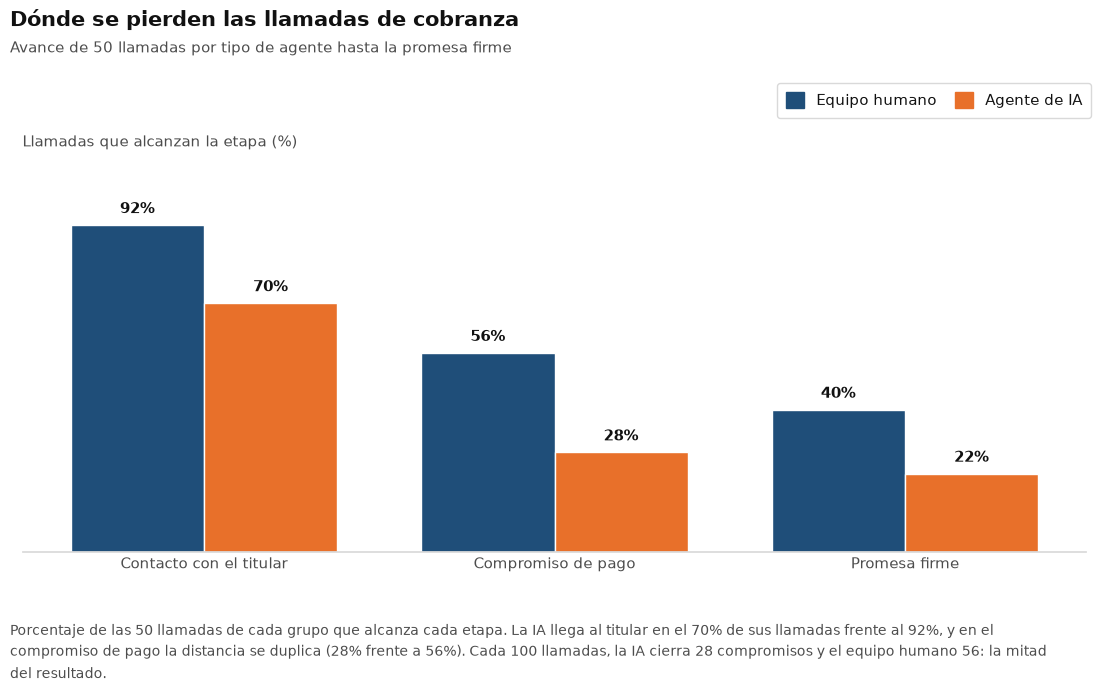

In [7]:
# Las dos primeras etapas del embudo son casi idénticas en ambos grupos: se conservan en la tabla y se omiten
# en el gráfico, donde solo ocuparían espacio sin mostrar diferencia.
PLOT_STAGES = ["Contacto con el titular", "Compromiso de pago", "Promesa firme"]
plot_funnel = funnel[funnel["Etapa"].isin(PLOT_STAGES)].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 5.2))
x = np.arange(len(plot_funnel))
width = 0.38
for i, g in enumerate(GROUPS):
    values = plot_funnel[g].to_numpy()
    bars = ax.bar(x + (i - 0.5) * width, values, width, color=PALETTE[g], zorder=2)
    for bar, value in zip(bars, values):
        ax.annotate(f"{value:.0%}", (bar.get_x() + bar.get_width() / 2, value), xytext=(0, 6),
                    textcoords="offset points", ha="center", va="bottom", fontsize=11, fontweight="bold", color=INK)

ax.set_xticks(x, list(plot_funnel["Etapa"]))
ax.set_yticks([])
ax.set_ylim(0, 1.1)
chart_frame(ax, ylabel="Llamadas que alcanzan la etapa (%)", keep=("bottom",))
agent_legend(fig)
fig.tight_layout(rect=(0, 0, 1, 0.91))

holder = funnel.set_index("Etapa").loc["Contacto con el titular"]
gap = funnel.set_index("Etapa").loc["Compromiso de pago"]
chart_title(fig, "Dónde se pierden las llamadas de cobranza",
            "Avance de 50 llamadas por tipo de agente hasta la promesa firme")
caption(fig,
        "Porcentaje de las 50 llamadas de cada grupo que alcanza cada etapa.",
        f"La IA llega al titular en el {holder['IA']:.0%} de sus llamadas frente al {holder['Humano']:.0%}, y en el "
        f"compromiso de pago la distancia se duplica ({gap['IA']:.0%} frente a {gap['Humano']:.0%}).",
        f"Cada 100 llamadas, la IA cierra {100 * gap['IA']:.0f} compromisos y el equipo humano "
        f"{100 * gap['Humano']:.0f}: la mitad del resultado.")
save_fig(fig, "01_embudo_gestion")

**Hallazgo.** Los grupos se separan en dos etapas. La IA llega al titular en el 70% de las llamadas frente al 92% de los humanos (−22 pp, IC 95% [7, 37], p = 0.009) y logra compromiso de pago en el 28% frente al 56% (−28 pp, IC 95% [9, 45], p = 0.008). Contestar el teléfono no difiere entre grupos (92% frente a 98%, p = 0.36).

### 2.1 Efecto condicional: conversión una vez contactado el titular
Aquí la pregunta cambia: con el titular al teléfono, ¿quién convierte mejor? Se reporta la razón de riesgos (RR) con IC de Katz y el **E-value**, que indica cuán fuerte tendría que ser un confusor no medido (por ejemplo, una cartera más difícil asignada a la IA) para explicar por completo la diferencia observada.

In [8]:
k = titulares.groupby("grupo", observed=True)["ptp_f"].agg(["sum", "count"]).astype(int)
(kh, nh), (ka, na) = k.loc["Humano"], k.loc["IA"]
ph, pa = kh / nh, ka / na
rr = ph / pa
se_log_rr = np.sqrt(1 / kh - 1 / nh + 1 / ka - 1 / na)
rr_lo, rr_hi = np.exp(np.log(rr) + np.array([-1.96, 1.96]) * se_log_rr)
d_lo, d_hi = newcombe_diff_ci(kh, nh, ka, na)

conditional = pd.DataFrame([{
    "Compromiso | titular, Humano": f"{ph:.1%} ({kh}/{nh})", "Compromiso | titular, IA": f"{pa:.1%} ({ka}/{na})",
    "Diferencia (pp)": f"{100 * (ph - pa):+.1f} [{100 * d_lo:.1f}, {100 * d_hi:.1f}]",
    "Razón de riesgos": f"{rr:.2f} [{rr_lo:.2f}, {rr_hi:.2f}]", "p (Fisher)": f"{fisher_p(kh, nh, ka, na):.3f}",
    "E-value (estimación)": f"{e_value(rr):.2f}", "E-value (límite del IC)": f"{e_value(rr_lo) if rr_lo > 1 else 1:.2f}",
}]).T.rename(columns={0: "Valor"})
display(conditional)

,Valor
"Compromiso | titular, Humano",60.9% (28/46)
"Compromiso | titular, IA",40.0% (14/35)
Diferencia (pp),"+20.9 [-1.0, 40.1]"
Razón de riesgos,"1.52 [0.95, 2.43]"
p (Fisher),0.075
E-value (estimación),2.41
E-value (límite del IC),1.00


**Hallazgo.** Con el titular al teléfono, los humanos convierten el 61% frente al 40% (RR = 1.52). La magnitud es relevante pero no alcanza significancia con esta muestra (IC 95% de la diferencia [−1, 40] pp, p = 0.075). El E-value de 2.41 indica que un confusor tendría que asociarse 2.4 veces tanto con el grupo como con el compromiso para anular la estimación puntual. Como el IC del RR incluye 1, la conclusión se enuncia como *evidencia sugestiva*, no concluyente.

### 2.2 ¿Por qué no se llega al titular?
La contactabilidad no depende solo del agente. Un número equivocado es un problema de la base de datos; un corte antes de la identificación sí es atribuible a la gestión.

In [9]:
CONTACT_LABELS = {
    "wrong_number": ("Número equivocado", "Base de datos"),
    "third_party": ("Contesta un tercero", "Base de datos u horario"),
    "voicemail": ("Buzón de voz", "Disponibilidad del cliente"),
    "no_answer": ("No contesta", "Disponibilidad del cliente"),
    "ivr": ("Sistema automático", "Disponibilidad del cliente"),
    "hangup_before_identification": ("Cuelga antes de identificarse", "Gestión del agente"),
}
no_contact = calls[~calls["es_titular"]]
contact_table = pd.crosstab(no_contact["contact_type"], no_contact["grupo"])
contact_table.index = pd.MultiIndex.from_tuples([CONTACT_LABELS[i] for i in contact_table.index],
                                                names=["Motivo", "Atribución probable"])
display(contact_table.sort_values("IA", ascending=False))

,grupo,Humano,IA
Motivo,Atribución probable,,
Número equivocado,Base de datos,0,6
Contesta un tercero,Base de datos u horario,3,4
Buzón de voz,Disponibilidad del cliente,1,3
Cuelga antes de identificarse,Gestión del agente,0,1
No contesta,Disponibilidad del cliente,0,1


**Hallazgo.** 10 de los 15 contactos fallidos de la IA son números equivocados (6) o terceros (4), frente a 3 de 4 en humanos. Los números equivocados apuntan a la calidad de la base asignada, no a la conducta del agente.

## 3. Tamaños de efecto por dimensión (Nivel 1)

**Pregunta:** ¿quién es mejor y en qué dimensión?

**Método.** Población: llamadas con el titular (efecto condicional). Para cada métrica se estima el **delta de Cliff** (IA − Humano), la probabilidad de que una llamada de IA puntúe más alto que una humana menos la probabilidad inversa. Tiene tres ventajas:
- no asume normalidad;
- está acotado en [−1, 1], lo que permite comparar métricas de escalas distintas;
- en variables binarias coincide con la diferencia de proporciones.

El IC 95% sale de 2000 remuestras bootstrap. Los p-valores provienen del test de Mann-Whitney (variables continuas y ordinales) o del test exacto de Fisher (binarias), y se ajustan por Benjamini-Hochberg sobre todas las métricas.

Cada métrica tiene una **dirección favorable** declarada de antemano: mayor es mejor, menor es mejor, o sin juicio de valor cuando la métrica describe estilo (duración, número de ofertas) y no calidad.

In [10]:
EFFECT_METRICS = [  # (columna, dimensión, dirección favorable)
    ("ptp_f", "Resultado", 1), ("promesa_firme_f", "Resultado", 1),
    ("final_outcome_rank", "Resultado", 1), ("pct_objections_resolved", "Resultado", 1),
    ("had_negotiation_f", "Negociación", 1), ("motivo_indagado", "Negociación", 1),
    ("n_offers_agent", "Negociación", 0), ("n_counteroffers_client", "Negociación", 0),
    ("pct_ofertas_descuento", "Negociación", 0),
    ("agent_latency_median_s", "Dinámica conversacional", -1), ("silencio_muerto_por_min", "Dinámica conversacional", -1),
    ("max_agent_monologue_s", "Dinámica conversacional", -1), ("mechanical_repetition_f", "Dinámica conversacional", -1),
    ("agent_misunderstood", "Dinámica conversacional", -1), ("backchannels_agent_per_min", "Dinámica conversacional", 1),
    ("agent_talk_share", "Dinámica conversacional", 0), ("words_per_min_agent", "Dinámica conversacional", 0),
    ("interruptions_per_min_client", "Dinámica conversacional", 0), ("conv_duration_s", "Dinámica conversacional", 0),
    ("cumplimiento_regulatorio", "Cumplimiento", 1), ("validates_identity_before_disclosing_f", "Cumplimiento", 1),
    ("gestion_cobro", "Cumplimiento", 1), ("mentions_credit_bureaus_f", "Cumplimiento", 1),
    ("clarity", "Calidad percibida", 1), ("empathy", "Calidad percibida", 1),
    ("active_listening", "Calidad percibida", 1), ("objection_handling", "Calidad percibida", 1),
    ("control_focus", "Calidad percibida", 1), ("professionalism", "Calidad percibida", 1),
    ("sentiment_delta", "Experiencia del cliente", 1), ("client_escalation", "Experiencia del cliente", -1),
    ("client_expresses_annoyance_f", "Experiencia del cliente", -1),
]
VERDICTS = {"nulo": "Diferencia no concluyente", "estilo": "Diferencia de estilo"}


def compare_groups(df, metrics):
    rows = []
    for col, dimension, direction in metrics:
        h, a = (df.loc[df["grupo"].eq(g), col].astype(float).dropna().to_numpy() for g in GROUPS)
        binary = set(np.unique(np.r_[h, a])) <= {0.0, 1.0}
        delta = cliffs_delta(a, h)
        lo, hi = bootstrap_ci(cliffs_delta, a, h)
        p = fisher_p(int(h.sum()), h.size, int(a.sum()), a.size) if binary else stats.mannwhitneyu(a, h).pvalue
        summary_fn = np.mean if binary else np.median
        rows.append({"Métrica": label(col), "Dimensión": dimension, "Dirección": direction,
                     "Resumen": "Proporción" if binary else "Mediana", "Humano": summary_fn(h), "IA": summary_fn(a),
                     "n Humano": h.size, "n IA": a.size, "Delta de Cliff": delta, "IC inf": lo, "IC sup": hi, "p": p})
    out = pd.DataFrame(rows)
    out["q (BH)"] = multipletests(out["p"], method="fdr_bh")[1]
    significant = out["q (BH)"] < 0.05
    favours_ai = np.sign(out["Delta de Cliff"]) * out["Dirección"] > 0
    out["Favorece a"] = np.select([~significant, out["Dirección"].eq(0), favours_ai],
                                  [VERDICTS["nulo"], VERDICTS["estilo"], "IA"], default="Humano")
    return out


effects = compare_groups(titulares, EFFECT_METRICS)
display(effects.drop(columns=["Dirección"]).style
        .format({"Humano": "{:.2f}", "IA": "{:.2f}", "Delta de Cliff": "{:+.2f}", "IC inf": "{:+.2f}",
                 "IC sup": "{:+.2f}", "p": "{:.4f}", "q (BH)": "{:.4f}"})
        .hide(axis="index"))

Métrica,Dimensión,Resumen,Humano,IA,n Humano,n IA,Delta de Cliff,IC inf,IC sup,p,q (BH),Favorece a
Compromiso de pago,Resultado,Proporción,0.61,0.40,46,35,-0.21,-0.42,+0.01,0.0755,0.1006,Diferencia no concluyente
Promesa firme,Resultado,Proporción,0.43,0.31,46,35,-0.12,-0.34,+0.11,0.3569,0.3938,Diferencia no concluyente
Resultado final de la llamada,Resultado,Mediana,6.00,3.00,46,35,-0.23,-0.47,+0.03,0.0645,0.0897,Diferencia no concluyente
Objeciones resueltas (%),Resultado,Mediana,100.00,0.00,37,27,-0.35,-0.57,-0.11,0.0100,0.0187,Humano
Hubo negociación,Negociación,Proporción,0.91,0.89,46,35,-0.03,-0.16,+0.11,0.7211,0.7211,Diferencia no concluyente
Obtiene el motivo de no pago,Negociación,Proporción,0.65,0.49,46,35,-0.17,-0.37,+0.04,0.1739,0.2061,Diferencia no concluyente
Ofertas del agente,Negociación,Mediana,1.00,2.00,46,35,+0.39,+0.15,+0.60,0.0020,0.0052,Diferencia de estilo
Contraofertas del cliente,Negociación,Mediana,0.00,0.00,46,35,-0.10,-0.31,+0.11,0.3768,0.4019,Diferencia no concluyente
Ofertas con descuento (%),Negociación,Mediana,0.00,0.50,31,31,+0.57,+0.32,+0.79,0.0001,0.0002,Diferencia de estilo
Tiempo en responder del agente (s),Dinámica conversacional,Mediana,0.74,2.29,44,29,+0.92,+0.79,+0.99,0.0000,0.0000,Humano


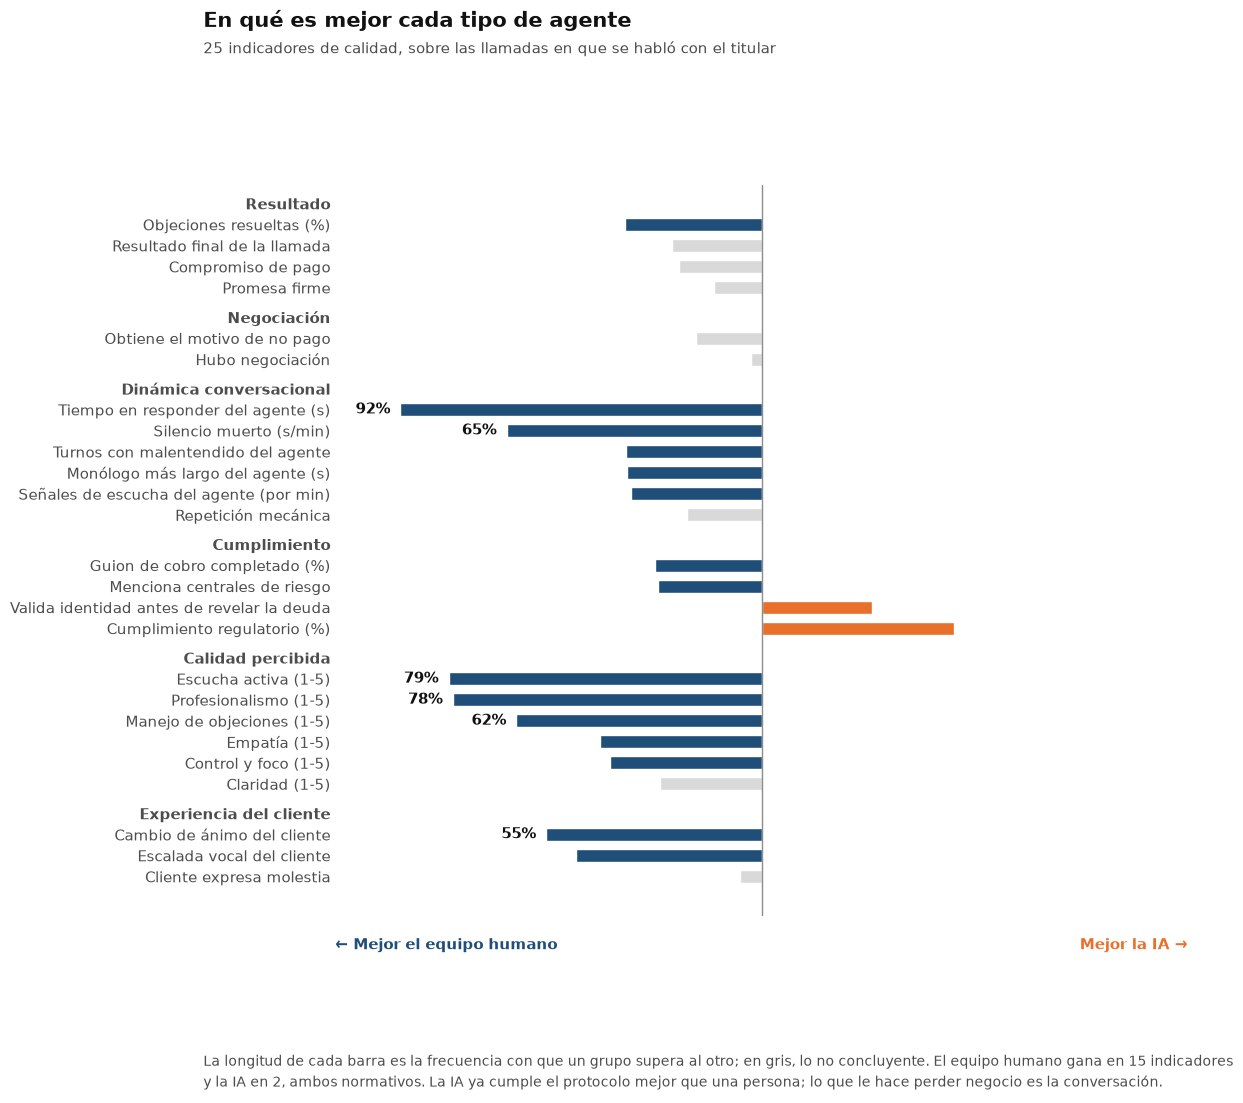

In [11]:
advantage = effects[effects["Dirección"].ne(0)].assign(
    ventaja=lambda d: d["Delta de Cliff"] * d["Dirección"],  # positivo = mejor la IA, negativo = mejor el humano
    claro=lambda d: d["Favorece a"].ne(VERDICTS["nulo"]))

fig, ax = plt.subplots(figsize=(11, 9.5))
y, yticks, ylabels, headers, positions = 0, [], [], [], {}
for dimension, block in advantage.groupby("Dimensión", sort=False):
    yticks.append(y); ylabels.append(dimension); headers.append(y); y -= 1
    for _, row in block.sort_values("ventaja").iterrows():
        color = PALETTE["IA"] if row["ventaja"] > 0 else PALETTE["Humano"]
        ax.barh(y, row["ventaja"], 0.62, color=color if row["claro"] else NEUTRAL, zorder=2)
        positions[row["Métrica"]] = (y, row["ventaja"], row["claro"])
        yticks.append(y); ylabels.append(row["Métrica"]); y -= 1
    y -= 0.4

for metric in advantage[advantage["claro"]].reindex(advantage["ventaja"].abs().sort_values(ascending=False).index)["Métrica"].head(6):
    pos, value, _ = positions[metric]
    ax.annotate(f"{abs(value):.0%}", (value, pos), xytext=(7 if value > 0 else -7, 0), textcoords="offset points",
                ha="left" if value > 0 else "right", va="center", fontsize=10.5, fontweight="bold", color=INK)

ax.axvline(0, color=MUTED, linewidth=1)
ax.set_yticks(yticks, ylabels)
for tick, position in zip(ax.get_yticklabels(), yticks):
    if position in headers:
        tick.set_fontweight("bold"); tick.set_color(INK)
ax.set_xlim(-1.08, 1.08)
ax.set_xticks([])
ax.annotate("← Mejor el equipo humano", (0.0, -0.045), xycoords="axes fraction", ha="left", fontsize=11,
            fontweight="bold", color=PALETTE["Humano"])
ax.annotate("Mejor la IA →", (1.0, -0.045), xycoords="axes fraction", ha="right", fontsize=11,
            fontweight="bold", color=PALETTE["IA"])
chart_frame(ax)
counts = advantage.loc[advantage["claro"], "Favorece a"].value_counts()
chart_title(fig, "En qué es mejor cada tipo de agente",
            "25 indicadores de calidad, sobre las llamadas en que se habló con el titular")
caption(fig,
        "La longitud de cada barra es la frecuencia con que un grupo supera al otro; en gris, lo no concluyente.",
        f"El equipo humano gana en {counts.get('Humano', 0)} indicadores y la IA en {counts.get('IA', 0)}, ambos normativos.",
        "La IA ya cumple el protocolo mejor que una persona; lo que le hace perder negocio es la conversación.")
save_fig(fig, "03_tamanos_de_efecto")

**Hallazgo.** Tras controlar la tasa de falsos descubrimientos, los humanos superan a la IA en 15 de 25 métricas de calidad y la IA gana en 2, ambas de cumplimiento regulatorio: valida la identidad antes de revelar la deuda en el 63% de las llamadas frente al 35%.
- **Mayores ventajas humanas:** la dinámica conversacional (latencia 0.74 s frente a 2.29 s, δ = +0.92; silencio muerto 0.7 frente a 4.6 s/min) y la experiencia del cliente, cuyo sentimiento mejora con humanos y empeora con IA (δ = −0.55), con más escalada vocal frente a la IA.
- **Negociación:** la IA hace más ofertas y concentra más descuentos (mediana 50% de sus ofertas frente a 0%) sin convertir más.
- **Rúbricas:** muestran diferencias grandes (escucha activa δ = −0.79), pero provienen de una anotación no ciega y se leen como apoyo.

## 4. Resultado final como escala ordinal (Nivel 1)

**Pregunta:** ¿la ventaja se limita a cruzar el umbral de "compromiso sí/no", o se sostiene a lo largo de toda la escala de resultados?

**Método.** Los ocho resultados anotados se agrupan en cinco niveles ordenados (se unen categorías con menos de 5 casos) y se ajusta una **regresión logística ordinal** (odds proporcionales) con el tipo de agente como predictor. El odds ratio (OR) indica cuánto se multiplican las odds de alcanzar un nivel superior con un agente humano. El supuesto de odds proporcionales se revisa ajustando una logística binaria en cada punto de corte: si los OR por corte son similares, el modelo ordinal es adecuado.

In [12]:
OUTCOME_LEVELS = {
    "no_contact": "Sin contacto con el titular", "third_party": "Sin contacto con el titular",
    "holder_refuses": "Sin acuerdo", "no_agreement": "Sin acuerdo",
    "callback_scheduled": "Seguimiento o pago declarado", "claims_already_paid": "Seguimiento o pago declarado",
    "vague_promise": "Promesa vaga", "firm_promise": "Promesa firme",
}
LEVEL_ORDER = list(dict.fromkeys(OUTCOME_LEVELS.values()))
calls["resultado_ord"] = pd.Categorical(calls["final_outcome"].map(OUTCOME_LEVELS), categories=LEVEL_ORDER, ordered=True)
titulares["resultado_ord"] = calls.loc[titulares.index, "resultado_ord"]


def fit_ordinal(df):
    y = df["resultado_ord"].cat.remove_unused_categories()
    x = df["grupo"].eq("Humano").astype(float).rename("Humano").to_frame()
    res = OrderedModel(y, x, distr="logit").fit(method="bfgs", disp=False)
    lo, hi = np.exp(res.conf_int().loc["Humano"])
    ordinal = {"OR Humano vs IA": np.exp(res.params["Humano"]), "IC inf": lo, "IC sup": hi, "p": res.pvalues["Humano"]}
    cuts = []
    for level in y.cat.categories[1:]:
        yb = (y >= level).astype(float)
        logit = sm.Logit(yb, sm.add_constant(x)).fit(disp=False)
        cl, ch = np.exp(logit.conf_int().loc["Humano"])
        cuts.append({"Corte": f"≥ {level}", "OR": np.exp(logit.params["Humano"]), "IC inf": cl, "IC sup": ch})
    return ordinal, pd.DataFrame(cuts)


ordinal_results = {}
for name, df in {"Todas las llamadas": calls, "Llamadas con el titular": titulares}.items():
    ordinal, cuts = fit_ordinal(df)
    ordinal_results[name] = ordinal
    print(f"\n{name}: chequeo de odds proporcionales (logística binaria por punto de corte)")
    display(cuts.style.format({"OR": "{:.2f}", "IC inf": "{:.2f}", "IC sup": "{:.2f}"}).hide(axis="index"))

ordinal_table = pd.DataFrame(ordinal_results).T
display(ordinal_table.style.format({"OR Humano vs IA": "{:.2f}", "IC inf": "{:.2f}", "IC sup": "{:.2f}", "p": "{:.4f}"}))


Todas las llamadas: chequeo de odds proporcionales (logística binaria por punto de corte)


Corte,OR,IC inf,IC sup
≥ Sin acuerdo,4.93,1.50,16.16
≥ Seguimiento o pago declarado,3.78,1.65,8.65
≥ Promesa vaga,3.27,1.42,7.52
≥ Promesa firme,2.36,0.98,5.68



Llamadas con el titular: chequeo de odds proporcionales (logística binaria por punto de corte)


Corte,OR,IC inf,IC sup
≥ Seguimiento o pago declarado,2.71,1.09,6.78
≥ Promesa vaga,2.33,0.95,5.73
≥ Promesa firme,1.68,0.67,4.22


,OR Humano vs IA,IC inf,IC sup,p
Todas las llamadas,3.45,1.64,7.27,0.0011
Llamadas con el titular,2.19,0.95,5.06,0.0665


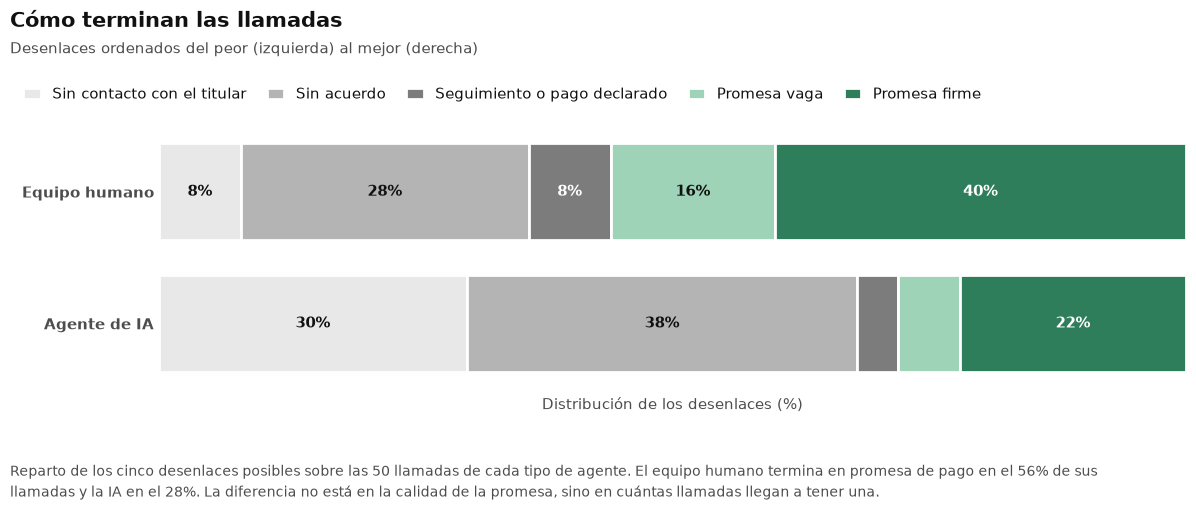

In [13]:
# Comparación directa entre tipos de agente sobre el total de llamadas: desdoblar además por población repetía
# la misma lectura en cuatro barras.
dist = pd.DataFrame({AGENT_LABEL[g]: calls.loc[calls["grupo"].eq(g), "resultado_ord"]
                     .value_counts(normalize=True).reindex(LEVEL_ORDER) for g in GROUPS}).T.fillna(0)
OUTCOME_COLORS = {"Sin contacto con el titular": "#E8E8E8", "Sin acuerdo": "#B4B4B4",
                  "Seguimiento o pago declarado": "#7C7C7C", "Promesa vaga": "#9FD3B8", "Promesa firme": POSITIVE}
DARK_OUTCOMES = {"Seguimiento o pago declarado", "Promesa firme"}  # fondo oscuro: la cifra se escribe en blanco

fig, ax = plt.subplots(figsize=(12, 3.6))
ypos = [1.0, 0.25]
left = np.zeros(len(dist))
for level in LEVEL_ORDER:
    widths = dist[level].to_numpy()
    bars = ax.barh(ypos, widths, left=left, height=0.55, color=OUTCOME_COLORS[level], edgecolor="white",
                   linewidth=2, label=level, zorder=2)
    ax.bar_label(bars, labels=[f"{w:.0%}" if w >= 0.08 else "" for w in widths], label_type="center",
                 color="white" if level in DARK_OUTCOMES else INK, fontsize=11, fontweight="bold")
    left += widths

ax.set_yticks(ypos, list(dist.index))
for tick, g in zip(ax.get_yticklabels(), GROUPS):
    tick.set_color(PALETTE[g]); tick.set_fontweight("bold")
ax.set_xlim(0, 1)
ax.set_xticks([])
chart_frame(ax, xlabel="Distribución de los desenlaces (%)")
fig.legend(loc="upper left", bbox_to_anchor=(0.005, 0.99), ncol=len(LEVEL_ORDER), fontsize=10.5,
           handlelength=1.2, columnspacing=1.4)
fig.tight_layout(rect=(0, 0, 1, 0.88))

promise = dist[["Promesa vaga", "Promesa firme"]].sum(axis=1)
chart_title(fig, "Cómo terminan las llamadas", "Desenlaces ordenados del peor (izquierda) al mejor (derecha)")
caption(fig,
        "Reparto de los cinco desenlaces posibles sobre las 50 llamadas de cada tipo de agente.",
        f"El equipo humano termina en promesa de pago en el {promise[AGENT_LABEL['Humano']]:.0%} de sus llamadas y la "
        f"IA en el {promise[AGENT_LABEL['IA']]:.0%}.",
        "La diferencia no está en la calidad de la promesa, sino en cuántas llamadas llegan a tener una.")
save_fig(fig, "04_resultado_ordinal")

**Hallazgo.** En las 100 llamadas, las odds de alcanzar un mejor resultado son 3.45 veces mayores con humanos (IC 95% [1.64, 7.27], p = 0.001). Entre titulares el OR baja a 2.19 (IC 95% [0.95, 5.06], p = 0.067). Los OR por punto de corte decrecen hacia la promesa firme (de 4.9 a 2.4 en todas las llamadas), con IC solapados: la ventaja humana pesa más en los primeros peldaños (contactar y llegar a un acuerdo) que en la calidad final de la promesa.

## 5. Manejo de objeciones: ¿mala elección de técnica o mala ejecución? (Nivel 2)

**Pregunta:** la IA resuelve menos objeciones. ¿Es porque elige técnicas menos efectivas (*mezcla*) o porque, con la misma técnica, obtiene peores resultados (*ejecución*)?

**Método.** La unidad de análisis es la objeción (97 casos en 64 llamadas). Las objeciones de una misma llamada no son independientes, por eso se usa un **GEE logístico** agrupado por llamada con correlación intercambiable. El GEE estima efectos poblacionales robustos a esa dependencia. Se prefirió frente a un modelo mixto porque con ~1.5 objeciones por llamada el intercepto aleatorio queda mal identificado.

Las siete técnicas se agrupan en tres familias para evitar celdas vacías: *adaptativa* (aclaración, oferta alternativa, reprogramación), *empática* y *guion o presión* (ignora y repite guion, consecuencias, escala). La brecha de resolución se reparte en mezcla y ejecución con una descomposición de Kitagawa, con IC por bootstrap de conglomerados (remuestreo de llamadas).

In [14]:
TECHNIQUES = {
    "clarification": ("Aclaración", "Adaptativa"), "alternative_offer": ("Oferta alternativa", "Adaptativa"),
    "reschedule": ("Reprogramación", "Adaptativa"), "empathy_validation": ("Empatía y validación", "Empática"),
    "ignores_repeats_script": ("Ignora y repite el guion", "Guion o presión"),
    "consequences": ("Advierte consecuencias", "Guion o presión"), "escalates": ("Escala la presión", "Guion o presión"),
}
obj = objections.assign(
    resuelta=objections["resolved"].eq("yes").astype(float),
    tecnica=objections["agent_technique"].map(lambda t: TECHNIQUES[t][0]),
    familia=objections["agent_technique"].map(lambda t: TECHNIQUES[t][1]),
    sin_dinero=objections["type"].eq("no_money").astype(float),
)

technique_rates = rate_table(obj, "tecnica", "resuelta")
family_rates = obj.groupby(["familia", "grupo"], observed=True)["resuelta"].agg(["mean", "count"]).unstack("grupo")
display(family_rates.style.format("{:.2f}").set_caption("Tasa de resolución y número de objeciones por familia de técnica"))

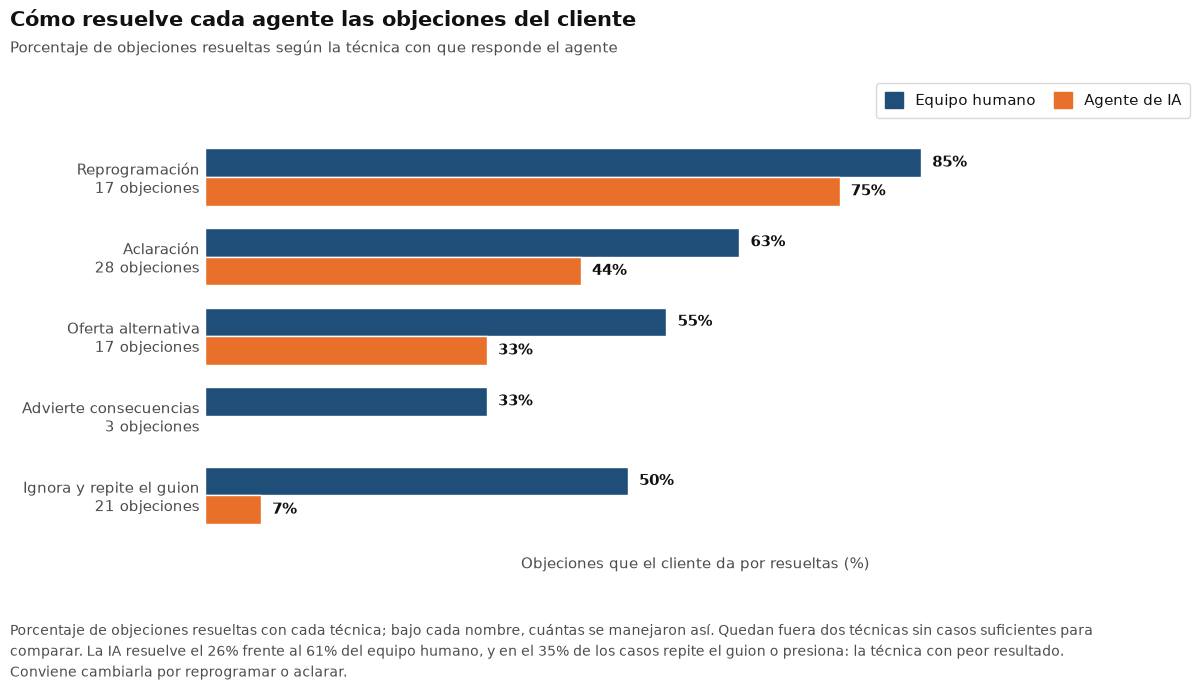

In [15]:
technique_counts = obj["tecnica"].value_counts()
# "Empatía y validación" y "Escala la presión" tienen una sola respuesta de uno de los dos agentes: la fila no
# permite comparar y la barra de ese agente ni siquiera es visible. Se omiten del gráfico; siguen en las tablas.
EXCLUDED_TECHNIQUES = {"Empatía y validación", "Escala la presión"}
tech_order = [t for t in obj.groupby("tecnica")["resuelta"].mean().sort_values(ascending=False).index
              if t not in EXCLUDED_TECHNIQUES]
tech_labels = [f"{t}\n{technique_counts[t]} objeci" + ("ones" if technique_counts[t] != 1 else "ón")
               for t in tech_order]

fig, ax = plt.subplots(figsize=(12, 5.2))
grouped_bars(ax, technique_rates, tech_order, tick_labels=tech_labels)
chart_frame(ax, xlabel="Objeciones que el cliente da por resueltas (%)")
agent_legend(fig)
fig.tight_layout(rect=(0, 0, 1, 0.92))

script_share_ai = obj.loc[obj["grupo"].eq("IA"), "familia"].eq("Guion o presión").mean()
resolved_h, resolved_ai = obj.groupby("grupo", observed=True)["resuelta"].mean()[GROUPS]
chart_title(fig, "Cómo resuelve cada agente las objeciones del cliente",
            "Porcentaje de objeciones resueltas según la técnica con que responde el agente")
caption(fig,
        "Porcentaje de objeciones resueltas con cada técnica; bajo cada nombre, cuántas se manejaron así. Quedan "
        "fuera dos técnicas sin casos suficientes para comparar.",
        f"La IA resuelve el {resolved_ai:.0%} frente al {resolved_h:.0%} del equipo humano, y en el {script_share_ai:.0%} "
        "de los casos repite el guion o presiona: la técnica con peor resultado.",
        "Conviene cambiarla por reprogramar o aclarar.")
save_fig(fig, "07_objeciones_por_tecnica")

In [16]:
GEE_SPECS = {
    "A. Tipo de agente": f"resuelta ~ {GROUP_FORMULA}",
    "B. + Familia de técnica": f"resuelta ~ {GROUP_FORMULA} + C(familia, Treatment('Adaptativa'))",
    "C. + Objeción por falta de dinero": f"resuelta ~ {GROUP_FORMULA} + C(familia, Treatment('Adaptativa')) + sin_dinero",
}
TERM_LABELS = {GROUP_TERM: "IA (ref. Humano)", "C(familia, Treatment('Adaptativa'))[T.Empática]": "Técnica empática (ref. adaptativa)",
               "C(familia, Treatment('Adaptativa'))[T.Guion o presión]": "Guion o presión (ref. adaptativa)",
               "sin_dinero": "Objeción por falta de dinero"}

gee_rows = []
for model_name, formula in GEE_SPECS.items():
    res = fit_gee(formula, obj)
    for term in res.params.index.drop("Intercept"):
        gee_rows.append({"Modelo": model_name, "Término": TERM_LABELS[term], **gee_odds_ratio(res, term)})
gee_table = pd.DataFrame(gee_rows)
display(gee_table.style.format({"OR": "{:.2f}", "IC inf": "{:.2f}", "IC sup": "{:.2f}", "p": "{:.4f}"}).hide(axis="index"))

mix = kitagawa(obj, "familia", "resuelta")
mix_boot = bootstrap_frame(obj, lambda d: kitagawa(d, "familia", "resuelta"), cluster="call_id")
mix_table = pd.DataFrame({"Estimación (pp)": 100 * mix, "IC 95% inferior": 100 * mix_boot.quantile(0.025),
                          "IC 95% superior": 100 * mix_boot.quantile(0.975), "Parte de la brecha": mix / mix["Brecha total"]})
mix_table = mix_table.rename(index={"Efecto composición": "Mezcla de técnicas", "Efecto tasa": "Ejecución dentro de la técnica"})
display(mix_table.style.format({"Estimación (pp)": "{:+.1f}", "IC 95% inferior": "{:+.1f}",
                                "IC 95% superior": "{:+.1f}", "Parte de la brecha": "{:.0%}"}))

Modelo,Término,OR,IC inf,IC sup,p
A. Tipo de agente,IA (ref. Humano),0.23,0.09,0.59,0.0021
B. + Familia de técnica,IA (ref. Humano),0.40,0.14,1.13,0.0840
B. + Familia de técnica,Técnica empática (ref. adaptativa),0.06,0.00,2.17,0.1241
B. + Familia de técnica,Guion o presión (ref. adaptativa),0.16,0.06,0.41,0.0002
C. + Objeción por falta de dinero,IA (ref. Humano),0.40,0.14,1.14,0.0870
C. + Objeción por falta de dinero,Técnica empática (ref. adaptativa),0.05,0.00,2.28,0.1253
C. + Objeción por falta de dinero,Guion o presión (ref. adaptativa),0.15,0.06,0.41,0.0002
C. + Objeción por falta de dinero,Objeción por falta de dinero,0.80,0.34,1.87,0.6011


,Estimación (pp),IC 95% inferior,IC 95% superior,Parte de la brecha
Brecha total,+35.5,+14.9,+54.9,100%
Mezcla de técnicas,+15.5,+6.1,+26.8,44%
Ejecución dentro de la técnica,+20.1,+0.1,+41.4,56%


**Hallazgo.** La IA resuelve el 26% de sus objeciones frente al 61% de los humanos (GEE: OR = 0.23, IC 95% [0.09, 0.59]). Controlando por la familia de técnica, el OR se atenúa a 0.40 (IC 95% [0.14, 1.13]).
- **Elección de técnica:** responder con guion o presión reduce las odds de resolución a la sexta parte frente a una técnica adaptativa (OR = 0.16, IC 95% [0.06, 0.41]), y la IA lo hace en el 35% de sus objeciones frente al 19%.
- **Descomposición:** 44% de la brecha es mezcla de técnicas (IC 95% [6, 27] pp) y 56% es ejecución (IC 95% [0, 41] pp). Incluso con técnicas adaptativas, la IA resuelve 47% frente a 67%.

**Implicación:** eliminar el recurso de ignorar y repetir el guion (7% de resolución en la IA, n = 15) y derivar esas objeciones a reprogramación o aclaración.

## 6. Gestión de ofertas: estrategia y aceptación (complementario)

**Pregunta:** ¿qué ofrece cada tipo de agente, en qué términos para el cliente y con qué éxito?

**Método.**
- **Unidad de análisis:** la oferta, en llamadas con el titular. Las ofertas de una misma llamada no son independientes, por eso las proporciones por oferta se comparan con **GEE logístico agrupado por llamada**, las proporciones por llamada con el test exacto de Fisher y la mezcla de tipos con un **test de permutación** que baraja la etiqueta de grupo entre llamadas. Los IC de las barras son de Wilson y tienen carácter descriptivo.
- **Familias de oferta:** *exige pago total*; *pago reducido* (cuota mínima o abono), y *concesión* (descuento o condonación, refinanciación, plazo adicional).
- **Agresividad comercial:**
  - abrir la negociación con una concesión, evaluado sobre el primer turno con oferta, porque un mismo turno puede contener varias ofertas;
  - conceder antes de que el cliente plantee cualquier objeción;
  - anunciar un descuento del 0%, es decir, una oferta de descuento cuyo monto iguala la deuda declarada.
- **Aceptación:** la anotación no incluye un campo de aceptación. Se considera aceptada la **última oferta vigente en el turno en que el titular se compromete a pagar**. Cada compromiso acepta una sola oferta, así que la tasa por oferta penaliza hacer muchas ofertas; por eso se complementa con la tasa de compromiso por llamada con oferta y con quién propuso los términos que cerraron el acuerdo.

In [17]:
OFFER_TYPES = {  # tipo anotado: (etiqueta, familia)
    "full_payment": ("Pago total", "Exige pago total"),
    "minimum_installment": ("Cuota mínima", "Pago reducido"),
    "partial_payment": ("Abono parcial", "Pago reducido"),
    "discount_forgiveness": ("Descuento o condonación", "Concesión"),
    "refinancing_restructuring": ("Refinanciación", "Concesión"),
    "extra_time": ("Plazo adicional", "Concesión"),
}
OFFER_FAMILIES = ["Exige pago total", "Pago reducido", "Concesión"]

first_objection_s = objections.groupby("call_id")["time_s"].min()
ofertas = (offers.drop(columns="grupo")
           .merge(titulares[["call_id", "grupo", "ptp_f", "time_to_ptp_s", "debt_amount"]], on="call_id")
           .sort_values(["call_id", "time_s", "offer_idx"], ignore_index=True))
ofertas = ofertas.assign(
    tipo=ofertas["type"].map(lambda t: OFFER_TYPES[t][0]),
    familia=ofertas["type"].map(lambda t: OFFER_TYPES[t][1]),
    concesion=ofertas["type"].map(lambda t: OFFER_TYPES[t][1] == "Concesión").astype(float),
    con_monto=ofertas["amount"].notna().astype(float),
    con_fecha=ofertas["date_text"].notna().astype(float),
    sin_objecion_previa=(~ofertas["call_id"].map(first_objection_s).lt(ofertas["time_s"])).astype(float),
    descuento_implicito=np.where(ofertas["type"].eq("discount_forgiveness"), 1 - ofertas["amount"] / ofertas["debt_amount"], np.nan),
)
ofertas["monto_y_fecha"] = ofertas["con_monto"] * ofertas["con_fecha"]
ofertas["descuento_nominal"] = ofertas["descuento_implicito"].le(0).astype(float).where(ofertas["descuento_implicito"].notna())

# Aceptada: última oferta vigente, de cualquiera de las partes, en el turno del compromiso de pago.
vigente = ofertas["ptp_f"].eq(1) & ofertas["time_s"].le(ofertas["time_to_ptp_s"])
ofertas["aceptada"] = 0.0
ofertas.loc[ofertas[vigente].groupby("call_id").tail(1).index, "aceptada"] = 1.0
ofertas_agente = ofertas[ofertas["proposed_by"].eq("agent")].copy()

opening_turn = ofertas_agente["time_s"].eq(ofertas_agente.groupby("call_id")["time_s"].transform("min"))
opening = (ofertas_agente[opening_turn].groupby("call_id")["concesion"].max().rename("abre_con_concesion"))
negociaciones = (ofertas_agente.groupby("call_id")
                 .agg(grupo=("grupo", "first"), ofertas_por_llamada=("tipo", "size"),
                      descuento_implicito=("descuento_implicito", "mean"), ofrece_descuento_0=("descuento_nominal", "max"),
                      ptp_f=("ptp_f", "first"))
                 .join(opening).reset_index())
negociaciones["grupo"] = pd.Categorical(negociaciones["grupo"], categories=GROUPS)

mix_p = call_permutation_p(ofertas_agente, lambda d: stats.chi2_contingency(pd.crosstab(d["grupo"], d["tipo"]))[0])
offers_per_call = [negociaciones.loc[negociaciones["grupo"].eq(g), "ofertas_por_llamada"] for g in GROUPS]
print(f"Ofertas del agente: Humano {int(offers_per_call[0].sum())} en {offers_per_call[0].size} llamadas, "
      f"IA {int(offers_per_call[1].sum())} en {offers_per_call[1].size} llamadas")
print(f"Ofertas por llamada con oferta (media): Humano {offers_per_call[0].mean():.2f}, IA {offers_per_call[1].mean():.2f}; "
      f"Mann-Whitney p = {stats.mannwhitneyu(*offers_per_call).pvalue:.3f}")
print(f"Mezcla de tipos de oferta: p de permutación por llamada = {mix_p:.4f}")

offer_mix = pd.crosstab(ofertas_agente["tipo"], ofertas_agente["grupo"])
display(offer_mix.div(offer_mix.sum()).join(offer_mix, rsuffix=" (n)").style.format("{:.0%}", subset=GROUPS)
        .set_caption("Participación de cada tipo en las ofertas del agente"))

strategy = pd.DataFrame({
    "Abre la negociación con una concesión (por llamada)": compare_rate(negociaciones, "abre_con_concesion", clustered=False),
    "Concesión sin objeción previa del cliente (por concesión)":
        compare_rate(ofertas_agente[ofertas_agente["concesion"].eq(1)], "sin_objecion_previa", clustered=True),
    "Anuncia un descuento del 0% (por llamada con descuento cuantificable)":
        compare_rate(negociaciones, "ofrece_descuento_0", clustered=False),
}).T
display(strategy.style.format(RATE_FORMAT))

Ofertas del agente: Humano 55 en 31 llamadas, IA 70 en 31 llamadas
Ofertas por llamada con oferta (media): Humano 1.77, IA 2.26; Mann-Whitney p = 0.033
Mezcla de tipos de oferta: p de permutación por llamada = 0.0215


grupo,Humano,IA,Humano (n),IA (n)
tipo,,,,
Abono parcial,7%,1%,4,1
Cuota mínima,31%,23%,17,16
Descuento o condonación,24%,44%,13,31
Pago total,20%,17%,11,12
Plazo adicional,11%,3%,6,2
Refinanciación,7%,11%,4,8


,Humano,IA,n Humano,n IA,Diferencia IA − Humano (pp),p
Abre la negociación con una concesión (por llamada),48%,100%,31,31,+52,0.0000
Concesión sin objeción previa del cliente (por concesión),43%,59%,23,41,+15,0.2152
Anuncia un descuento del 0% (por llamada con descuento cuantificable),0%,28%,9,29,+28,0.1591


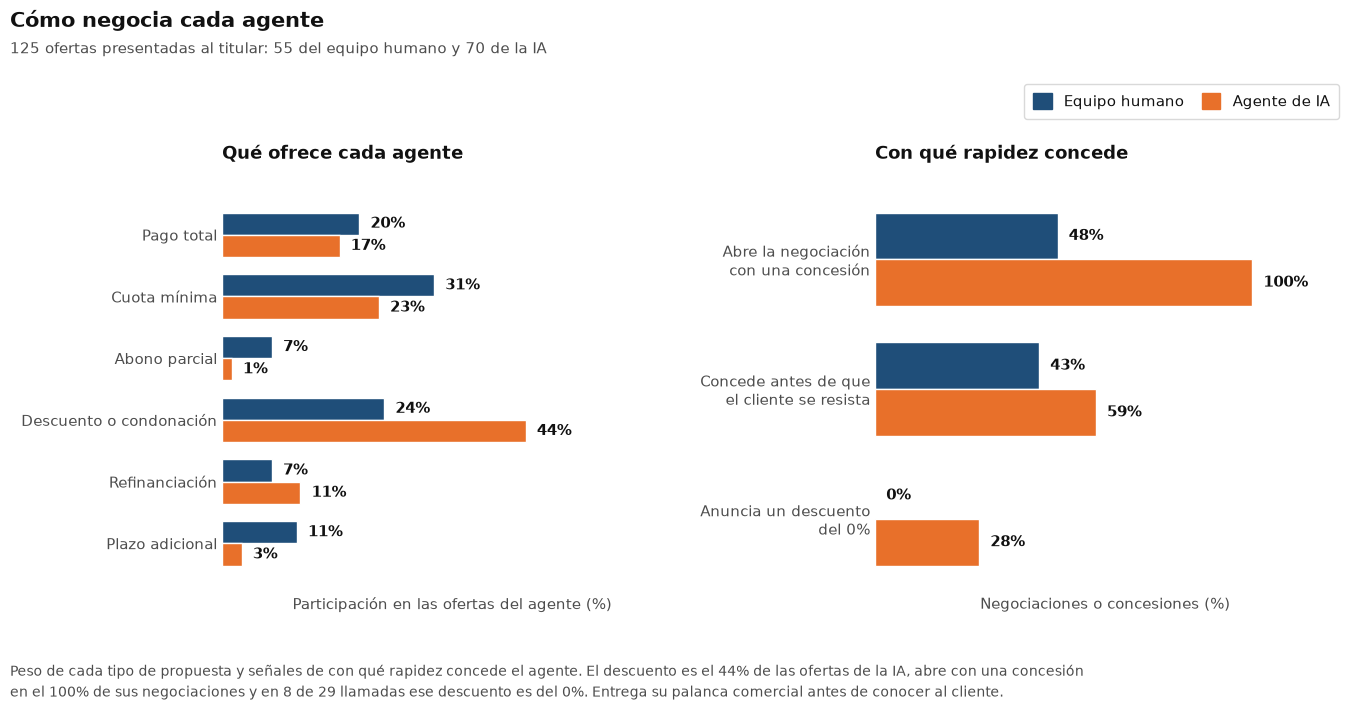

In [18]:
type_order = (ofertas_agente.groupby("tipo")
              .agg(familia=("familia", "first"), n=("familia", "size"))
              .assign(orden=lambda d: d["familia"].map(OFFER_FAMILIES.index))
              .sort_values(["orden", "n"], ascending=[True, False]).index.tolist())
type_rates = indicator_rates({t: (ofertas_agente.assign(es_tipo=ofertas_agente["tipo"].eq(t).astype(float)), "es_tipo")
                              for t in type_order})
AGGRESSIVENESS = {
    "Abre la negociación\ncon una concesión": (negociaciones, "abre_con_concesion"),
    "Concede antes de que\nel cliente se resista": (ofertas_agente[ofertas_agente["concesion"].eq(1)], "sin_objecion_previa"),
    "Anuncia un descuento\ndel 0%": (negociaciones, "ofrece_descuento_0"),
}
aggressiveness_rates = indicator_rates(AGGRESSIVENESS)

fig, (ax_mix, ax_aggr) = plt.subplots(1, 2, figsize=(13.5, 5.6))
grouped_bars(ax_mix, type_rates, type_order)
chart_frame(ax_mix, title="Qué ofrece cada agente", xlabel="Participación en las ofertas del agente (%)")
grouped_bars(ax_aggr, aggressiveness_rates, list(AGGRESSIVENESS))
chart_frame(ax_aggr, title="Con qué rapidez concede", xlabel="Negociaciones o concesiones (%)")
agent_legend(fig)
fig.tight_layout(rect=(0, 0, 1, 0.90))

aggr = aggressiveness_rates.set_index(["categoria", "grupo"])
opens = aggr.loc["Abre la negociación\ncon una concesión", "tasa"]
zero = aggr.loc[("Anuncia un descuento\ndel 0%", "IA")]
mix = type_rates.set_index(["categoria", "grupo"])["tasa"].loc["Descuento o condonación"]
chart_title(fig, "Cómo negocia cada agente",
            "125 ofertas presentadas al titular: 55 del equipo humano y 70 de la IA")
caption(fig,
        "Peso de cada tipo de propuesta y señales de con qué rapidez concede el agente.",
        f"El descuento es el {mix['IA']:.0%} de las ofertas de la IA, abre con una concesión en el {opens['IA']:.0%} de sus "
        f"negociaciones y en {int(zero['k'])} de {int(zero['n'])} llamadas ese descuento es del 0%.",
        "Entrega su palanca comercial antes de conocer al cliente.")
save_fig(fig, "10_estrategia_ofertas")

**Hallazgo.** La IA negocia con más ofertas y más descuento: hace 2.26 ofertas por llamada con negociación frente a 1.77 (Mann-Whitney p = 0.033), y el 44% de sus ofertas son descuentos o condonaciones, frente al 24% en humanos (mezcla de tipos distinta, p de permutación = 0.021).
- **Apertura:** la IA abre con una concesión en sus 31 negociaciones, frente al 48% de los humanos (p < 0.001). En la revisión de transcripciones, esa apertura es una frase de guion: "Queremos ofrecerle un descuento del X% de toda la deuda".
- **Descuento del 0%:** en 8 de las 29 llamadas de la IA con descuento cuantificable, el monto ofrecido iguala la deuda declarada; la frase anuncia literalmente "un descuento del 0%". En humanos no ocurre en ninguna de 9 llamadas (p = 0.16, muestra pequeña).
- **Concesión anticipada:** conceder antes de que el cliente objete no difiere de forma concluyente (59% frente a 43%, p = 0.22).

**Implicación:** la IA entrega su principal palanca de negociación al inicio, antes de conocer la capacidad de pago del cliente, y un descuento del 0% presentado como beneficio resta credibilidad a la oferta. Conviene condicionar el descuento a una objeción de liquidez indagada y bloquear en el guion los descuentos nulos.

In [19]:
acceptance = pd.DataFrame({
    "Oferta del agente aceptada (por oferta)": compare_rate(ofertas_agente, "aceptada", clustered=True),
    "Compromiso de pago en llamadas con oferta del agente (por llamada)": compare_rate(negociaciones, "ptp_f", clustered=False),
}).T
display(acceptance.style.format(RATE_FORMAT))

acceptance_models = pd.DataFrame([
    {"Modelo": "A. Tipo de agente", **gee_odds_ratio(fit_gee(f"aceptada ~ {GROUP_FORMULA}", ofertas_agente), GROUP_TERM)},
    {"Modelo": "B. + Familia de oferta",
     **gee_odds_ratio(fit_gee(f"aceptada ~ {GROUP_FORMULA} + C(familia, Treatment('Exige pago total'))", ofertas_agente), GROUP_TERM)},
])
display(acceptance_models.style.format({"OR": "{:.2f}", "IC inf": "{:.2f}", "IC sup": "{:.2f}", "p": "{:.4f}"})
        .set_caption("GEE por llamada: odds de aceptación de la IA frente a los humanos").hide(axis="index"))

closing = ofertas[ofertas["aceptada"].eq(1)]
closing_counts = pd.crosstab(closing["grupo"], closing["proposed_by"].map({"agent": "Agente", "client": "Cliente"})).reindex(GROUPS)
closing_p = fisher_p(int(closing_counts.loc["Humano", "Cliente"]), int(closing_counts.loc["Humano"].sum()),
                     int(closing_counts.loc["IA", "Cliente"]), int(closing_counts.loc["IA"].sum()))
display(closing_counts.style.set_caption(f"Quién propuso los términos aceptados (Fisher p = {closing_p:.3f})"))

,Humano,IA,n Humano,n IA,Diferencia IA − Humano (pp),p
Oferta del agente aceptada (por oferta),25%,11%,55,70,-14,0.0328
Compromiso de pago en llamadas con oferta del agente (por llamada),68%,45%,31,31,-23,0.1236


Modelo,OR,IC inf,IC sup,p
A. Tipo de agente,0.39,0.17,0.93,0.0328
B. + Familia de oferta,0.42,0.17,1.06,0.0669


proposed_by,Agente,Cliente
grupo,,
Humano,14,12
IA,8,6


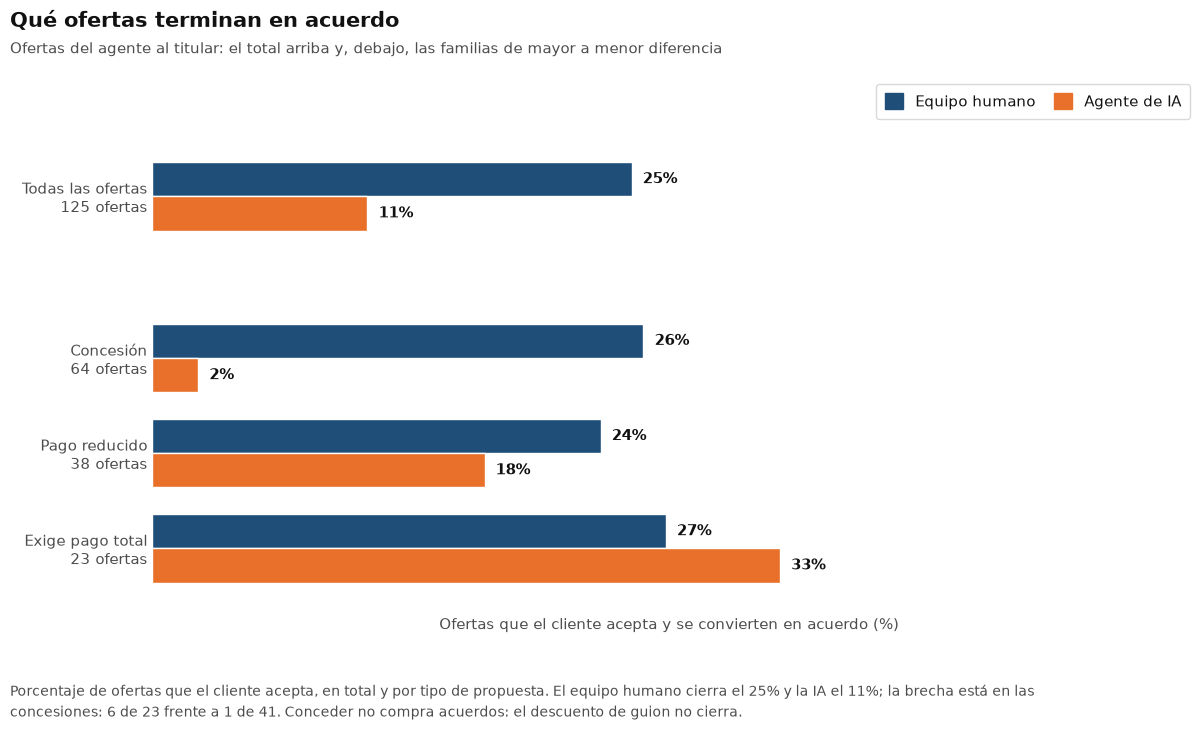

In [20]:
family_frames = {"Todas las ofertas": (ofertas_agente, "aceptada")} | {
    family: (ofertas_agente[ofertas_agente["familia"].eq(family)], "aceptada") for family in OFFER_FAMILIES}
acceptance_rates = indicator_rates(family_frames)
family_counts = acceptance_rates.groupby("categoria")["n"].sum()
# El total encabeza, separado; debajo las familias ordenadas por la diferencia entre agentes, de mayor a menor:
# así la fila que explica la brecha queda inmediatamente después del resumen.
gaps = acceptance_rates.pivot(index="categoria", columns="grupo", values="tasa").pipe(
    lambda d: (d["Humano"] - d["IA"]).drop(index="Todas las ofertas").sort_values(ascending=False))
order = ["Todas las ofertas"] + gaps.index.tolist()
labels = [f"{name}\n{int(family_counts[name])} ofertas" for name in order]

fig, ax = plt.subplots(figsize=(12, 5.8))
grouped_bars(ax, acceptance_rates, order, tick_labels=labels, gap_after=0)
chart_frame(ax, xlabel="Ofertas que el cliente acepta y se convierten en acuerdo (%)")
agent_legend(fig)
fig.tight_layout(rect=(0, 0, 1, 0.91))

acc = acceptance_rates.set_index(["categoria", "grupo"])
concession_ai, concession_h = acc.loc[("Concesión", "IA")], acc.loc[("Concesión", "Humano")]
all_offers = acc.loc["Todas las ofertas", "tasa"]
chart_title(fig, "Qué ofertas terminan en acuerdo",
            "Ofertas del agente al titular: el total arriba y, debajo, las familias de mayor a menor diferencia")
caption(fig,
        "Porcentaje de ofertas que el cliente acepta, en total y por tipo de propuesta.",
        f"El equipo humano cierra el {all_offers['Humano']:.0%} y la IA el {all_offers['IA']:.0%}; la brecha está en las "
        f"concesiones: {int(concession_h['k'])} de {int(concession_h['n'])} frente a {int(concession_ai['k'])} de "
        f"{int(concession_ai['n'])}.",
        "Conceder no compra acuerdos: el descuento de guion no cierra.")
save_fig(fig, "12_aceptacion_ofertas")

**Hallazgo.** El 25% de las ofertas humanas termina aceptado frente al 11% de las de la IA (GEE: OR = 0.39, IC 95% [0.17, 0.93], p = 0.033). Al ajustar por familia de oferta, el OR apenas cambia (0.42, IC 95% [0.17, 1.06]): la menor aceptación no se explica por el tipo de oferta.
- **Concesiones:** la diferencia se concentra aquí. Solo 1 de las 41 concesiones de la IA cierra un acuerdo (2%), frente a 6 de 23 en humanos (26%).
- **Por llamada:** en llamadas con oferta del agente, el compromiso de pago es del 68% en humanos y del 45% en la IA (p = 0.12).
- **Quién fija los términos:** en ambos grupos, cerca de la mitad de los acuerdos se cierra sobre una propuesta del cliente (46% y 43%, p = 1.00).

**Implicación:** el descuento de guion de la IA no funciona como palanca de cierre. Reservarlo para el momento en que el cliente plantea una objeción de liquidez, con una profundidad acorde a esa objeción, es la hipótesis de mejora más directa para probar en un experimento.

## 7. Manejo de objeciones: calidad de la respuesta y conversión en compromiso (complementario)

La sección 7 mostró *qué técnica* elige cada agente. Esta sección examina *cómo* responde, a partir del texto de las transcripciones, y si superar la objeción se traduce en un compromiso de pago.

**Método.**
- **Marcadores de la respuesta del agente,** medidos con reglas léxicas reproducibles sobre el turno de respuesta anotado:
  - *Valida la situación del cliente:* reconoce explícitamente su situación o su sentir ("entiendo", "comprendo", "lamento", "tiene razón").
  - *Pregunta abierta de indagación:* la respuesta contiene una pregunta que empieza, en sus primeras palabras, con una partícula interrogativa (qué, cómo, cuándo, cuánto, cuál, dónde, para qué, por qué). No cuentan las preguntas de cierre ("¿confirmamos el acuerdo?") ni los ofrecimientos de explicar ("¿le explico cómo funciona?").
  - *Mejora el sentimiento del cliente:* el siguiente turno del cliente puntúa al menos 0.10 más que el turno de la objeción, en la escala P(positivo) − P(negativo).
- **Validación de los marcadores:** la validación léxica se contrasta con la técnica anotada *empatía y validación*. Se descartó un marcador de eco léxico (retomar las palabras del cliente): en la revisión de transcripciones capturaba palabras genéricas y crecía con la longitud del guion.
- **Asociación con la resolución:** GEE logístico por llamada, `resuelta ~ tipo de agente + marcador`, un modelo por marcador.
- **De la negativa al compromiso:** llamadas con al menos una objeción. El compromiso se estratifica por el estado final (la última objeción de la llamada se superó o no) y la brecha se descompone con Kitagawa: cuánto se debe a que la IA supera menos objeciones (*composición*) y cuánto a que convierte menos aun cuando las supera (*tasa*). **Compromiso vinculante:** promesa firme con términos confirmados por el cliente.

**Cautela.** Los marcadores léxicos miden la forma de la respuesta, no su sinceridad: un "entiendo" de guion cuenta igual que uno genuino. Por eso se leen junto con la resolución y el sentimiento posterior del cliente.

In [21]:
CANONICAL_DIR = EXTRACTION_DIR / "interim" / "canonical"
TURNS_PATH = EXTRACTION_DIR / "processed" / "turns.parquet"
RESPONSES_PATH = TABLES_DIR / "respuestas_objeciones.csv"


def clean_text(text):
    return re.sub(r"\s+", " ", (text or "").replace("[CENSURADO]", " ")).strip()


def fold(text):
    """Minúsculas sin tildes, para que las reglas léxicas no dependan de la ortografía del ASR."""
    return "".join(c for c in unicodedata.normalize("NFD", text.lower()) if unicodedata.category(c) != "Mn")


def extract_objection_responses():
    """Por objeción: texto de la objeción y de la respuesta, sentimiento del cliente antes y después, latencia de la respuesta."""
    turns = pd.read_parquet(TURNS_PATH).sort_values(["call_id", "start_s"])
    rows = []
    for call_id, block in objections.groupby("call_id"):
        text = {t["turn_id"]: clean_text(t["text"])
                for t in json.loads((CANONICAL_DIR / f"{call_id}.json").read_text(encoding="utf-8"))["turns"]}
        call_turns = turns[turns["call_id"].eq(call_id)].set_index("turn_id")
        client = call_turns[call_turns["role"].eq("CLIENT") & call_turns["sentiment"].notna()]
        for o in block.itertuples():
            has_response = isinstance(o.response_turn_id, str)
            start = call_turns.at[o.turn_id, "start_s"]
            response_start = call_turns.at[o.response_turn_id, "start_s"] if has_response else start
            before = client.loc[client["start_s"].le(start), "sentiment"]
            after = client.loc[client["start_s"].gt(response_start), "sentiment"]
            rows.append({"call_id": call_id, "objection_idx": o.objection_idx, "texto_objecion": text[o.turn_id],
                         "texto_respuesta": text[o.response_turn_id] if has_response else "",
                         "sentimiento_antes": before.iloc[-1] if len(before) else np.nan,
                         "sentimiento_despues": after.iloc[0] if len(after) else np.nan,
                         "latencia_respuesta_s": call_turns.at[o.response_turn_id, "latency_s"] if has_response else np.nan})
    return pd.DataFrame(rows)


if CANONICAL_DIR.exists() and TURNS_PATH.exists():
    responses = extract_objection_responses()
    responses.to_csv(RESPONSES_PATH, index=False)
else:  # repositorio público sin transcripciones: se usa la tabla derivada ya exportada
    responses = pd.read_csv(RESPONSES_PATH).fillna({"texto_objecion": "", "texto_respuesta": ""})
print(f"Objeciones con texto: {len(responses)}; tabla derivada en {RESPONSES_PATH}")

Objeciones con texto: 97; tabla derivada en ../outputs/tablas/respuestas_objeciones.csv


In [22]:
EMPATHY_RE = re.compile(r"\b(entiendo|comprendo|lamento|lo siento|que pena|tiene (toda la )?razon|esta en (todo )?su derecho"
                        r"|me imagino|no se preocupe|le agradezco)\b")
QUESTION_RE = re.compile(r"¿([^?]*)\?")
OPEN_QUESTION_RE = re.compile(r"^\s*(?:\w+[\s,]+){0,2}?(qué|cómo|por qué|cuándo|cuánto|cuánta|cuántos|cuántas|cuál|cuáles|dónde|para qué)\b")
OFFER_TO_EXPLAIN_RE = re.compile(r"^\s*(le|te)\s+(explico|cuento|digo|comento|muestro)\b")
SENTIMENT_MIN_CHANGE = 0.10
RESPONSE_MARKERS = ["validacion_empatica", "pregunta_abierta", "mejora_sentimiento"]


def asks_open_question(text):
    return any(OPEN_QUESTION_RE.search(q) and not OFFER_TO_EXPLAIN_RE.search(q) for q in QUESTION_RE.findall(text.lower()))


obj = obj.drop(columns=responses.columns.drop(["call_id", "objection_idx"]), errors="ignore").merge(
    responses, on=["call_id", "objection_idx"], validate="one_to_one")
# Sin respuesta anotada, o turno de respuesta idéntico al de la objeción (artefacto de diarización): marcadores no evaluables.
obj["respuesta_valida"] = obj["texto_respuesta"].ne("") & obj["texto_respuesta"].ne(obj["texto_objecion"])
text_markers = {
    "validacion_empatica": obj["texto_respuesta"].map(lambda t: EMPATHY_RE.search(fold(t)) is not None),
    "pregunta_abierta": obj["texto_respuesta"].map(asks_open_question),
}
for name, values in text_markers.items():
    obj[name] = np.where(obj["respuesta_valida"], values.astype(float), np.nan)
obj["delta_sentimiento"] = obj["sentimiento_despues"] - obj["sentimiento_antes"]
obj["mejora_sentimiento"] = obj["delta_sentimiento"].ge(SENTIMENT_MIN_CHANGE).astype(float).where(obj["delta_sentimiento"].notna())

annotated_empathy = obj["tecnica"].eq("Empatía y validación").map({True: "Técnica anotada: empatía y validación", False: "Otra técnica anotada"})
display(pd.crosstab(annotated_empathy, obj["validacion_empatica"].map({1.0: "Con validación léxica", 0.0: "Sin validación léxica"}),
                    normalize="index").style.format("{:.0%}")
        .set_caption("Validación de la regla léxica contra la técnica anotada (proporción por fila)"))

marker_tests = pd.DataFrame({label(m): compare_rate(obj, m, clustered=True) for m in RESPONSE_MARKERS}).T
marker_tests["q (BH)"] = multipletests(marker_tests["p"].astype(float), method="fdr_bh")[1]
display(marker_tests.style.format(RATE_FORMAT | {"q (BH)": "{:.4f}"}))

continuous_rows = []
for col in ["latencia_respuesta_s", "delta_sentimiento"]:
    data = obj.dropna(subset=[col])
    medians = data.groupby("grupo", observed=True)[col].median()
    perm_p = call_permutation_p(data, lambda d, c=col: abs(d.groupby("grupo")[c].median().diff().iloc[-1]))
    continuous_rows.append({"Métrica": label(col), "Mediana Humano": medians["Humano"], "Mediana IA": medians["IA"],
                            "p de permutación por llamada": perm_p})
display(pd.DataFrame(continuous_rows).style
        .format({"Mediana Humano": "{:.2f}", "Mediana IA": "{:.2f}", "p de permutación por llamada": "{:.4f}"}).hide(axis="index"))

resolution_or = pd.DataFrame([{"marcador": m, "Marcador": label(m),
                               **gee_odds_ratio(fit_gee(f"resuelta ~ {GROUP_FORMULA} + {m}", obj.dropna(subset=[m])), m)}
                              for m in RESPONSE_MARKERS])
display(resolution_or.drop(columns="marcador").style.format({"OR": "{:.2f}", "IC inf": "{:.2f}", "IC sup": "{:.2f}", "p": "{:.4f}"})
        .set_caption("GEE por llamada: odds de resolución con el marcador, ajustadas por tipo de agente").hide(axis="index"))

validacion_empatica,Con validación léxica,Sin validación léxica
tecnica,,
Otra técnica anotada,45%,55%
Técnica anotada: empatía y validación,100%,0%


,Humano,IA,n Humano,n IA,Diferencia IA − Humano (pp),p,q (BH)
Valida la situación del cliente,29%,78%,52,41,+49,0.0000,0.0001
Pregunta abierta de indagación,25%,15%,52,41,-10,0.1722,0.2582
Mejora el ánimo del cliente,68%,61%,50,33,-7,0.5043,0.5043


Métrica,Mediana Humano,Mediana IA,p de permutación por llamada
Tiempo en responder (s),1.10,3.26,0.0005
Cambio de ánimo tras la respuesta,0.41,0.28,0.3813


Marcador,OR,IC inf,IC sup,p
Valida la situación del cliente,1.26,0.44,3.63,0.6638
Pregunta abierta de indagación,1.45,0.43,4.86,0.5482
Mejora el ánimo del cliente,1.46,0.64,3.32,0.3712


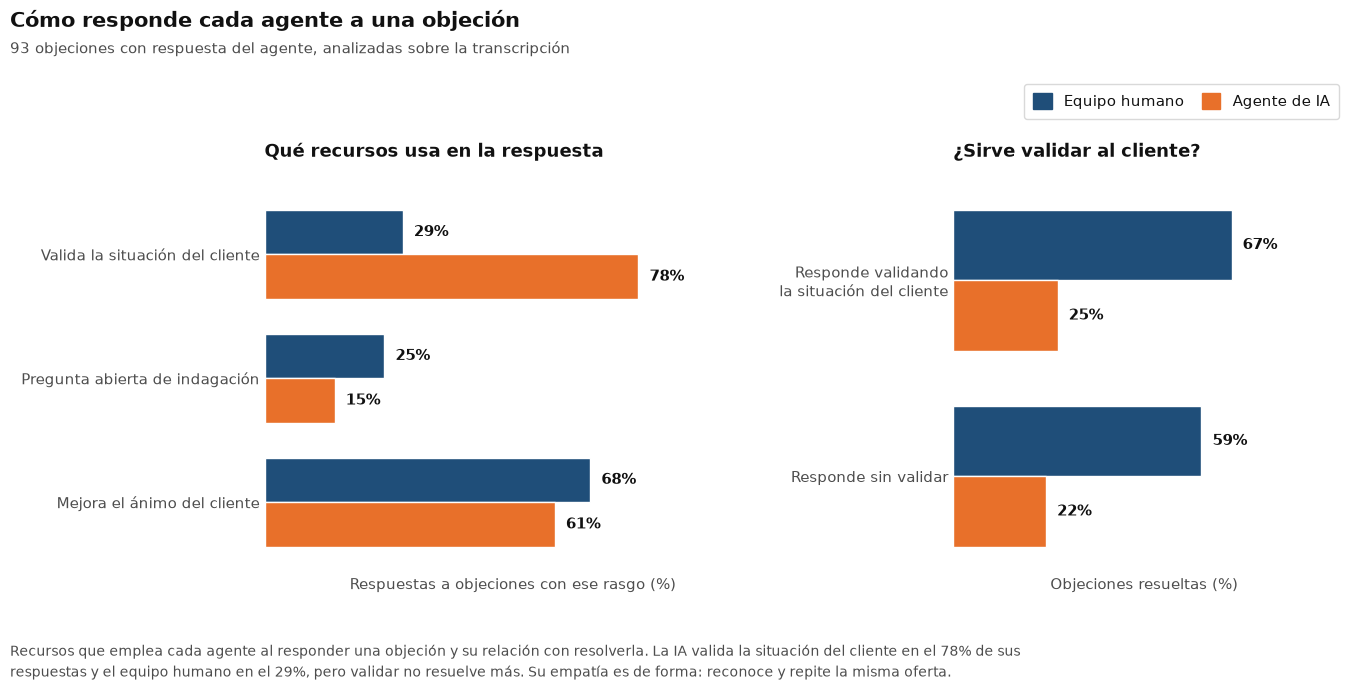

In [23]:
marker_order = [label(m) for m in RESPONSE_MARKERS]
marker_rates = indicator_rates({label(m): (obj, m) for m in RESPONSE_MARKERS})
VALIDATION_LABELS = {1.0: "Responde validando\nla situación del cliente", 0.0: "Responde sin validar"}
validation_rates = rate_table(obj.dropna(subset=["validacion_empatica"])
                              .assign(validacion=lambda d: d["validacion_empatica"].map(VALIDATION_LABELS)),
                              "validacion", "resuelta")

fig, (ax_markers, ax_effect) = plt.subplots(1, 2, figsize=(13.5, 5.4), gridspec_kw={"width_ratios": [1.3, 1]})
grouped_bars(ax_markers, marker_rates, marker_order)
chart_frame(ax_markers, title="Qué recursos usa en la respuesta", xlabel="Respuestas a objeciones con ese rasgo (%)")
grouped_bars(ax_effect, validation_rates, list(VALIDATION_LABELS.values()))
chart_frame(ax_effect, title="¿Sirve validar al cliente?", xlabel="Objeciones resueltas (%)")
agent_legend(fig)
fig.tight_layout(rect=(0, 0, 1, 0.90))

validation = marker_rates.set_index(["categoria", "grupo"])["tasa"].loc[label("validacion_empatica")]
chart_title(fig, "Cómo responde cada agente a una objeción",
            "93 objeciones con respuesta del agente, analizadas sobre la transcripción")
caption(fig,
        "Recursos que emplea cada agente al responder una objeción y su relación con resolverla.",
        f"La IA valida la situación del cliente en el {validation['IA']:.0%} de sus respuestas y el equipo humano en el "
        f"{validation['Humano']:.0%}, pero validar no resuelve más.",
        "Su empatía es de forma: reconoce y repite la misma oferta.")
save_fig(fig, "13_respuesta_objeciones")

**Hallazgo.** La IA valida la situación del cliente en el 78% de sus respuestas a objeciones, frente al 29% de los humanos (q < 0.001), casi siempre con fórmulas como "Entiendo perfectamente su situación". Esa validación no se asocia con resolver la objeción (OR = 1.26, IC 95% [0.44, 3.63]).
- **Indagación:** los humanos formulan más preguntas abiertas (25% frente a 15%), aunque la diferencia no es significativa (q = 0.26).
- **Latencia:** los humanos responden unas tres veces más rápido (mediana 1.1 s frente a 3.3 s, p de permutación < 0.01).
- **Sentimiento:** mejora tras la respuesta en proporciones similares (68% frente a 61%).
- **Validez de la regla:** la fórmula aparece en el 100% de las respuestas anotadas como *empatía y validación*, pero también en el 45% de las respuestas con otra técnica. La validación verbal funciona sobre todo como entrada a otra técnica, no como técnica en sí.

**Implicación:** en la IA, la empatía es de forma más que de fondo: reconoce la situación y a continuación repite la oferta (ver ejemplos más abajo). Mejorar la escucha activa pasa por indagar la capacidad de pago y adaptar la propuesta, no por añadir frases de validación.

In [24]:
OBJECTION_FAMILIES = {
    "no_money": "Falta de liquidez", "wants_discount": "Falta de liquidez",
    "wrong_amount": "Disputa del saldo", "doesnt_recognize_debt": "Disputa del saldo", "already_paid": "Disputa del saldo",
    "distrust_who_is_calling": "Confianza o disponibilidad", "call_later": "Confianza o disponibilidad",
    "annoyed_by_calls": "Confianza o disponibilidad", "asks_for_human": "Confianza o disponibilidad",
    "other": "Otra",
}
obj["familia_objecion"] = obj["type"].map(OBJECTION_FAMILIES)
objection_family_order = obj["familia_objecion"].value_counts().index[::-1].tolist()

last_resolved = obj.sort_values("objection_idx").groupby("call_id")["resuelta"].last()
FINAL_STATE = {1.0: "Última objeción superada", 0.0: "Objeción no superada"}
objection_calls = titulares[titulares["n_objections"].gt(0)].assign(
    ultima_superada=lambda d: d["call_id"].map(last_resolved),
    estado_final=lambda d: d["call_id"].map(last_resolved).map(FINAL_STATE),
    compromiso_vinculante=lambda d: (d["promesa_firme_f"].eq(1) & d["ptp_confirmed_by_client"].eq("true")).astype(float),
)
conversion = pd.DataFrame({
    "Última objeción superada": compare_rate(objection_calls, "ultima_superada", clustered=False),
    "Compromiso de pago": compare_rate(objection_calls, "ptp_f", clustered=False),
    "Compromiso vinculante (promesa firme con términos confirmados)": compare_rate(objection_calls, "compromiso_vinculante", clustered=False),
}).T
display(conversion.style.format(RATE_FORMAT).set_caption("Llamadas con al menos una objeción"))

refusal = kitagawa(objection_calls, "estado_final", "ptp_f")
# El bootstrap copia la tabla 2000 veces: se remuestrean solo las columnas que entran en el cálculo.
refusal_boot = bootstrap_frame(objection_calls[["call_id", "grupo", "estado_final", "ptp_f"]],
                               lambda d: kitagawa(d, "estado_final", "ptp_f"))
refusal_table = pd.DataFrame({
    "Estimación (pp)": 100 * refusal,
    "IC 95% inferior": 100 * refusal_boot.quantile(0.025),
    "IC 95% superior": 100 * refusal_boot.quantile(0.975),
}).rename(index={"Efecto composición": "Supera menos objeciones (composición)",
                 "Efecto tasa": "Convierte menos con igual desenlace de la objeción (tasa)"})
display(refusal_table.style.format("{:+.1f}"))

examples = (obj[obj["respuesta_valida"] & obj["familia_objecion"].eq("Falta de liquidez")]
            .groupby(["grupo", "resuelta"], observed=True).sample(1, random_state=SEED)
            .assign(Resuelta=lambda d: d["resuelta"].map({1.0: "Sí", 0.0: "No"}),
                    Cliente=lambda d: d["texto_objecion"].map(lambda t: textwrap.shorten(t, 180, placeholder=" [...]")),
                    Agente=lambda d: d["texto_respuesta"].map(lambda t: textwrap.shorten(t, 240, placeholder=" [...]")))
            .rename(columns={"grupo": "Tipo de agente", "tecnica": "Técnica anotada"}))
display(examples[["Tipo de agente", "Resuelta", "Técnica anotada", "Cliente", "Agente"]].style.hide(axis="index")
        .set_properties(**{"text-align": "left", "white-space": "normal"})
        .set_caption("Ejemplos de la transcripción: objeciones por falta de liquidez resueltas y no resueltas"))

,Humano,IA,n Humano,n IA,Diferencia IA − Humano (pp),p
Última objeción superada,65%,33%,37,27,-32,0.0220
Compromiso de pago,57%,37%,37,27,-20,0.1368
Compromiso vinculante (promesa firme con términos confirmados),27%,26%,37,27,-1,1.0000


,Estimación (pp),IC 95% inferior,IC 95% superior
Brecha total,+19.7,-4.9,+43.3
Supera menos objeciones (composición),+17.8,+4.1,+34.8
Convierte menos con igual desenlace de la objeción (tasa),+1.9,-19.3,+23.7


Tipo de agente,Resuelta,Técnica anotada,Cliente,Agente
Humano,No,Reprogramación,"Eh, sí, ya queda para el veinticinco, pero la verdad no, no, no pude cuadrarlo hasta aquí de mañana. Sí, señor. Pues, si yo puedo, lo hago mañana, si no, la otra semana que [...]",¿Para qué día realizaría el pago?
Humano,Sí,Reprogramación,así como le digo que estoy desempleado no es que me quede difícil,comprendemos pero usted ya le aplicó un descuento sobre el valor de su deuda y con solo 60 mil pesos quedaría el día ¿para cuándo usted podría realizar este pago para no que no pierda los beneficios?
IA,No,Ignora y repite el guion,"No, no, yo porque me llaman y eso no, no, no, no tengo, no tengo pues problema por, por eso. Mientras que pueda contestar yo contesto, sino que sí, sí se me hace muy, muy [...]","Entiendo, pero le soy honesto, el valor que le presenté es el mínimo que el sistema nos aprueba hoy, no está en mis manos bajarlo más. ¿Usted con cuánto podría comprometerse menos?"
IA,Sí,Ignora y repite el guion,"¿Cuándo sería el pago de la primera cuota? Porque necesito saber para cuándo Porque eso a quemar ropa, pues no sé si las tengo ¿Cuándo sería el pago de la primera cuota?","Entiendo su solicitud. Pero la primera cuota debe ser a más tardar el 8 de julio, como le mencioné. ¿Puede confirmarme si está de acuerdo con esa fecha o necesitamos ajustar el acuerdo?"


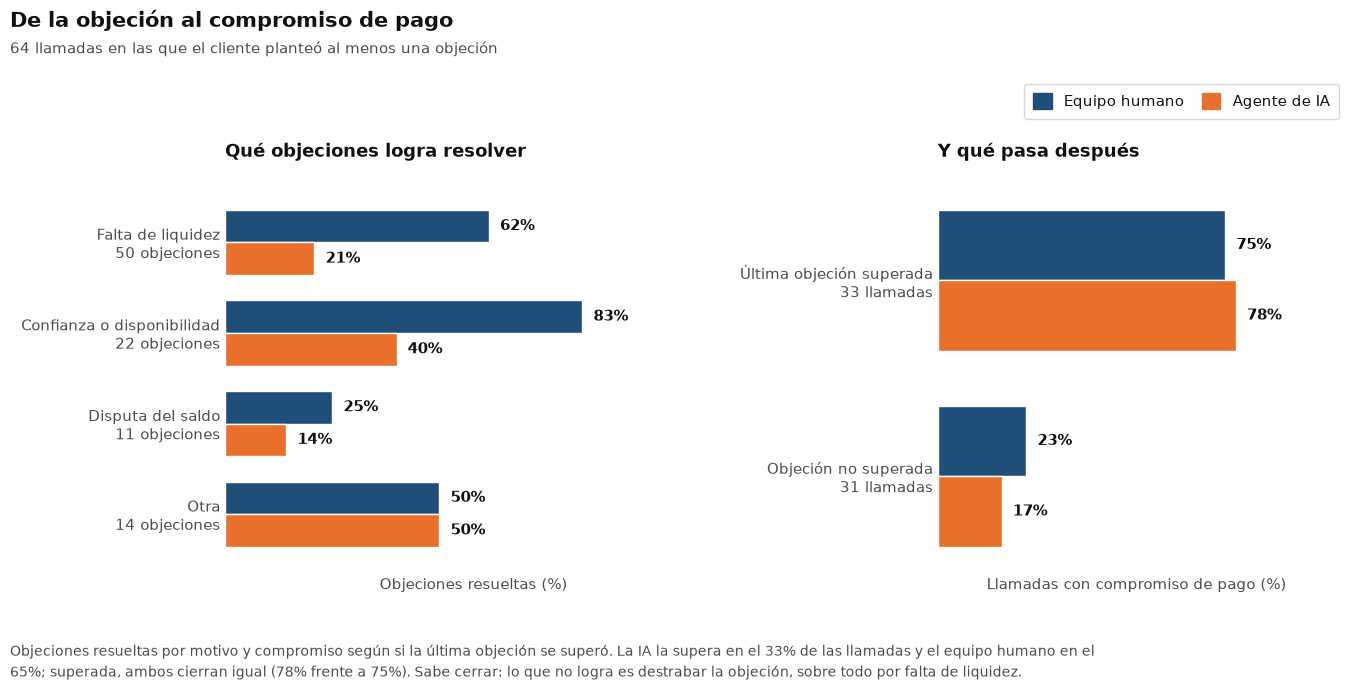

In [25]:
family_resolution = rate_table(obj, "familia_objecion", "resuelta")
family_counts = family_resolution.groupby("categoria")["n"].sum()
family_order = ["Falta de liquidez", "Confianza o disponibilidad", "Disputa del saldo", "Otra"]
family_labels = [f"{f}\n{int(family_counts[f])} objeciones" for f in family_order]
state_order = list(FINAL_STATE.values())
conversion_by_state = rate_table(objection_calls, "estado_final", "ptp_f")
state_counts = conversion_by_state.groupby("categoria")["n"].sum()
state_labels = [f"{s}\n{int(state_counts[s])} llamadas" for s in state_order]

fig, (ax_fam, ax_state) = plt.subplots(1, 2, figsize=(13.5, 5.4), gridspec_kw={"width_ratios": [1.25, 1]})
grouped_bars(ax_fam, family_resolution, family_order, tick_labels=family_labels)
chart_frame(ax_fam, title="Qué objeciones logra resolver", xlabel="Objeciones resueltas (%)")
grouped_bars(ax_state, conversion_by_state, state_order, tick_labels=state_labels)
chart_frame(ax_state, title="Y qué pasa después", xlabel="Llamadas con compromiso de pago (%)")
agent_legend(fig)
fig.tight_layout(rect=(0, 0, 1, 0.90))

by_state = conversion_by_state.set_index(["categoria", "grupo"])["tasa"].loc[FINAL_STATE[1.0]]
overcome = conversion.loc["Última objeción superada"]
chart_title(fig, "De la objeción al compromiso de pago",
            f"{int(overcome['n Humano']) + int(overcome['n IA'])} llamadas en las que el cliente planteó al menos una objeción")
caption(fig,
        "Objeciones resueltas por motivo y compromiso según si la última objeción se superó.",
        f"La IA la supera en el {overcome['IA']:.0%} de las llamadas y el equipo humano en el {overcome['Humano']:.0%}; "
        f"superada, ambos cierran igual ({by_state['IA']:.0%} frente a {by_state['Humano']:.0%}).",
        "Sabe cerrar: lo que no logra es destrabar la objeción, sobre todo por falta de liquidez.")
save_fig(fig, "14_objeciones_a_compromiso")

**Hallazgo.** En las llamadas con objeciones, los humanos superan la última objeción en el 65% de los casos, frente al 33% de la IA (p = 0.022).
- **Con la objeción superada,** la IA convierte igual que los humanos (78% frente a 75% de compromiso); sin superarla, ambos convierten poco (17% frente a 23%).
- **Descomposición:** de los 20 pp de brecha en compromiso, 18 pp (IC 95% [4, 35]) se deben a que la IA supera menos objeciones, y solo 2 pp a que convierta peor ante el mismo desenlace.
- **Por tipo de objeción:** la brecha de resolución es mayor en falta de liquidez (21% frente a 62%) y en confianza o disponibilidad (40% frente a 83%).
- **Calidad del compromiso:** el compromiso vinculante (promesa firme con términos confirmados) alcanza al 26% de las llamadas de la IA y al 27% de las humanas. La ventaja humana adicional está en promesas vagas o sin confirmación explícita.

**Implicación:** la palanca de conversión de la IA ante objeciones no es el cierre, sino superar la objeción, sobre todo la de liquidez. Rediseñar esa rama del flujo (indagar capacidad, ofrecer cuota o fecha alternativa en lugar de repetir la oferta) ataca el componente principal de la brecha en estas llamadas.

## 8. Síntesis: hallazgos accionables

1. **Resultado.** La IA logra compromiso de pago en el **28%** de las llamadas frente al **56%** de los humanos, una diferencia de **28 pp** (IC 95% [9, 45], p = 0.008).
2. **Contactabilidad.** La IA llega al titular en el **70%** de las llamadas frente al **92%** de los humanos, y 6 de sus 15 contactos fallidos son números equivocados. *Acción:* validar la base antes de asignarla a la IA.
3. **Objeciones.** La IA resuelve el **26%** de las objeciones frente al **61%**. En el 35% de los casos responde repitiendo el guion o presionando, lo que reduce las odds de resolución a la sexta parte. *Acción:* sustituir ese recurso por reprogramación y aclaración, que resuelven 85% y 63% en humanos.
4. **Cumplimiento.** La IA valida la identidad antes de revelar la deuda en el **63%** de las llamadas frente al **35%** de los humanos. *Acción:* llevar ese estándar al equipo humano mediante QA.
5. **Negociación.** El **44%** de las ofertas de la IA son descuentos o condonaciones, frente al **24%** en humanos, sin que eso se traduzca en más conversión. *Acción:* condicionar el descuento a una objeción de falta de dinero previamente indagada.
6. **Experiencia frente a conversión.** La IA responde 3 veces más lento (2.3 s frente a 0.7 s) y el ánimo del cliente empeora durante la llamada. *Acción:* tratar la latencia como mejora de experiencia y priorizar el contenido del flujo: oferta, objeciones y cierre.
7. **Ofertas.** La IA abre sus 31 negociaciones con un descuento de guion (humanos: 48%) y en 8 llamadas ese descuento es del 0%. Solo **1 de sus 41 concesiones** termina aceptada, frente a 6 de 23 en humanos. *Acción:* retirar el descuento de la apertura, ofrecerlo tras indagar una objeción de liquidez y bloquear los descuentos nulos.
8. **De la objeción al compromiso.** Superada la objeción, la IA convierte igual que los humanos (78% frente a 75%). De los 20 pp de brecha en llamadas con objeciones, **18 pp** se deben a que supera menos objeciones (33% frente a 65%). Su validación verbal es frecuente (78% de las respuestas) pero no se asocia con resolver. *Acción:* sustituir la fórmula de validación seguida de la misma oferta por indagación de capacidad de pago y una alternativa concreta.

### 8.1 Tamaño de muestra para confirmar la brecha condicional
La brecha entre titulares (61% frente a 40%) no alcanza significancia con 81 llamadas. Este cálculo estima cuántos contactos con el titular por brazo necesitaría un experimento aleatorizado para detectarla con 80% de potencia. También cuantifica un posible artefacto de grabación que condiciona la lectura de los cierres.

In [26]:
effect_h = proportion_effectsize(ph, pa)
n_per_arm = NormalIndPower().solve_power(effect_size=effect_h, alpha=0.05, power=0.8, ratio=1)
unclear_close = titulares.groupby("grupo", observed=True)["closing_by"].apply(lambda s: s.eq("cut_unclear").mean())
print(f"h de Cohen = {effect_h:.2f}; contactos con el titular necesarios por brazo (alfa = 0.05, potencia = 0.80): {np.ceil(n_per_arm):.0f}")
print("Llamadas con el titular cuyo cierre no es identificable: " + ", ".join(f"{g} {v:.0%}" for g, v in unclear_close.items()))

h de Cohen = 0.42; contactos con el titular necesarios por brazo (alfa = 0.05, potencia = 0.80): 89
Llamadas con el titular cuyo cierre no es identificable: Humano 11%, IA 60%


### 8.2 Limitaciones y próximos pasos

| Limitación | Consecuencia | Mitigación aplicada o propuesta |
|---|---|---|
| Las variables anotadas solo tienen autoconsistencia (1 de 20 llamadas gold) y el anotador identificó el tipo de agente en el 95% de los casos | Posible sesgo en rúbricas y resultados anotados | Titulares apoyados en variables deterministas; rúbricas solo como apoyo. Propuesta: gold humano de 20 llamadas |
| Estudio observacional sin datos de campaña, mora o monto | Confusión por cartera | E-value de 2.41 para el efecto condicional. Propuesta: experimento aleatorizado con el tamaño calculado arriba |
| Muestra de 81 llamadas con el titular | Poco poder para diferencias moderadas | Tamaños de efecto con IC y control FDR en lugar de p-valores aislados |
| Alta proporción de cierres no identificables en la IA | Posible truncado de grabaciones | Cierre cortés excluido de los índices. Propuesta: verificar el final de los audios |
| La anotación no registra la aceptación de cada oferta | La aceptación se infiere como la última oferta vigente al momento del compromiso | La tasa por oferta se complementa con el compromiso por llamada y con quién propuso los términos |
| Marcadores de respuesta a objeciones basados en reglas léxicas | Miden la forma de la respuesta, no su calidad percibida | Validados contra la técnica anotada; el marcador de eco léxico se descartó tras revisar transcripciones |
| Transcripciones fuera del repositorio público | Los marcadores no se pueden recalcular desde el texto original | Tabla derivada exportada en `outputs/tablas/respuestas_objeciones.csv`, que el notebook usa si faltan las transcripciones |